# 02b - Chignolin Edge-Transformer CV

Experimental notebook: same chignolin setup as `02`, but the CV model is built from edge states with triangular attention.


In [1]:
# Requires: pip install -e .

import json
import math
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from course_project.utils import resolve_device
from course_project.peptide import (
    build_split_tensors,
    compute_norm_stats,
    ids_for_mutants,
    load_target_table,
    traj_slice,
    clip_traj,
)



/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading mutant data


In [2]:
device = torch.device(resolve_device('cuda'))
force_train = True
print('device:', device)

# Data
peptide_dir = Path('../data/peptide')
packed_path = peptide_dir / 'hlda_trajectories_compact.pt'
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'

num_runs = 10
num_workers = 1
train_mutant_count = 22
val_mutant_count = 6
exclude_mutants = {}

history = 1
frames_per_traj = 10000

# Edge-transformer model and training params
hidden_size = 92
CVs = 14
edge_layers = 1
heads = 1
dropout = 0.005
batch_size = 256
learning_rate = 1e-4
weight_decay = 0.0
cls_weight = 0.5
time_lag_steps = 0
time_lag_weight = 0
epochs = 14
eval_every = 2

w_spearman = 0.5
w_pearson = 0.5

target_df = load_target_table(tm_csv, mfpt_csv, evalue_csv)
target_mutants = set(target_df['mutant'].astype(str).tolist())

packed = torch.load(packed_path, weights_only=False)
x_raw = packed['x'].float()
time_all = packed['time'].float()
offsets = packed['traj_offsets'].long()
labels = packed['labels'].long()
mutants = list(packed['mutants'])

x_all = x_raw
n_feat = int(x_all.shape[1])

uniq_mutants = sorted({
    m for m in set(mutants)
    if str(m).strip().upper() not in exclude_mutants and str(m) in target_mutants
})
print('packed path:', packed_path)
print('feature count:', n_feat)
print('all usable mutants:', len(uniq_mutants))





device: cuda
packed path: ../data/peptide/hlda_trajectories_compact.pt
feature count: 29
all usable mutants: 37


In [3]:
class SequenceHistoryNodeEncoder(nn.Module):
    def __init__(self, feat_dim, history, hidden_size):
        super().__init__()
        self.in_proj = nn.Linear(history, hidden_size)
        self.desc_emb = nn.Parameter(torch.randn(feat_dim, hidden_size) * 0.01)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.in_proj.weight)
        nn.init.zeros_(self.in_proj.bias)
        nn.init.normal_(self.desc_emb, mean=0.0, std=0.01)

    def forward(self, x_hist):
        x_desc = x_hist.transpose(1, 2)
        return self.in_proj(x_desc) + self.desc_emb.unsqueeze(0)


class TriangularAttention(nn.Module):
    def __init__(self, hidden_size, heads, dropout):
        super().__init__()
        assert hidden_size % heads == 0
        self.hidden_size = hidden_size
        self.heads = heads
        self.head_dim = hidden_size // heads
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v1_proj = nn.Linear(hidden_size, hidden_size)
        self.v2_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (self.q_proj, self.k_proj, self.v1_proj, self.v2_proj, self.out_proj):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        b, n, _, d = x.shape
        q = self.q_proj(x).view(b, n, n, self.heads, self.head_dim)
        k = self.k_proj(x).view(b, n, n, self.heads, self.head_dim)
        v1 = self.v1_proj(x).view(b, n, n, self.heads, self.head_dim)
        v2 = self.v2_proj(x).view(b, n, n, self.heads, self.head_dim)

        scores = torch.einsum('bilhd,bljhd->biljh', q, k) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=2)
        attn = self.dropout(attn)
        values = v1.unsqueeze(3) * v2.unsqueeze(1)
        out = torch.einsum('biljh,biljhd->bijhd', attn, values).reshape(b, n, n, d)
        return self.out_proj(out)


class EdgeTransformerLayer(nn.Module):
    def __init__(self, hidden_size, heads, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size)
        self.attn = TriangularAttention(hidden_size, heads, dropout)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, 4 * hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * hidden_size, hidden_size),
        )
        self.dropout = nn.Dropout(dropout)
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.ffn:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class EdgeCVReadout(nn.Module):
    def __init__(self, hidden_size, cv_count, heads, dropout):
        super().__init__()
        self.cv_queries = nn.Parameter(torch.randn(cv_count, hidden_size) * 0.01)
        self.pool = nn.MultiheadAttention(hidden_size, heads, dropout=dropout, batch_first=True)
        self.cv_heads = nn.ModuleList([nn.Linear(hidden_size, 1) for _ in range(cv_count)])
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.cv_queries, mean=0.0, std=0.01)
        for head in self.cv_heads:
            nn.init.xavier_uniform_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, edge_states):
        b, n, _, d = edge_states.shape
        edge_tokens = edge_states.view(b, n * n, d)
        rows = []
        for i, head in enumerate(self.cv_heads):
            q = self.cv_queries[i].view(1, 1, d).expand(b, 1, d)
            pooled, _ = self.pool(q, edge_tokens, edge_tokens, need_weights=False)
            rows.append(head(pooled.squeeze(1)))
        return torch.cat(rows, dim=1)


class ChignolinEdgeTransformerCV(nn.Module):
    def __init__(self, feat_dim, history, hidden, cv_count, edge_layers, heads, dropout):
        super().__init__()
        self.feat_dim = feat_dim
        self.hidden = hidden
        self.cv_count = cv_count
        self.node_encoder = SequenceHistoryNodeEncoder(feat_dim, history, hidden)
        self.left_proj = nn.Linear(hidden, hidden)
        self.right_proj = nn.Linear(hidden, hidden)
        self.edge_layers = nn.ModuleList([EdgeTransformerLayer(hidden, heads, dropout) for _ in range(edge_layers)])
        self.cv_readout = EdgeCVReadout(hidden, cv_count, heads, dropout)
        self.decoder_seed = nn.Linear(cv_count, feat_dim * hidden)
        self.decoder = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )
        self.decoder_tau = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )
        self.cls_head = nn.Sequential(
            nn.Linear(cv_count, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (self.left_proj, self.right_proj, self.decoder_seed):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
        for seq in (self.decoder, self.decoder_tau, self.cls_head):
            for module in seq.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    nn.init.zeros_(module.bias)

    def _init_edge_states(self, node_tokens):
        left = self.left_proj(node_tokens).unsqueeze(2)
        right = self.right_proj(node_tokens).unsqueeze(1)
        return left + right

    def forward(self, x_hist):
        node_tokens = self.node_encoder(x_hist)
        edge_states = self._init_edge_states(node_tokens)
        for layer in self.edge_layers:
            edge_states = layer(edge_states)

        cv = self.cv_readout(edge_states)
        decoded = self.decoder_seed(cv).view(x_hist.size(0), self.feat_dim, self.hidden)
        fused = torch.cat([node_tokens, decoded], dim=-1)
        dv_pred = self.decoder(fused).squeeze(-1)
        tau_pred = self.decoder_tau(fused).squeeze(-1)
        cls_logit = self.cls_head(cv).squeeze(-1)
        return dv_pred, tau_pred, cls_logit, cv


### Training

This follows the same data flow as `02`, but swaps in an edge-state model with triangular attention.


In [4]:
def run_epoch(loader, train_mode=True):
    model.train(train_mode)
    loss_sum = 0.0
    dv_loss_sum = 0.0
    tau_loss_sum = 0.0
    cls_loss_sum = 0.0
    n = 0
    y_true = []
    y_prob = []

    for xh, y_dv, y_tau, y_cls, traj_id in loader:
        xh = xh.to(device)
        y_dv = y_dv.to(device)
        y_tau = y_tau.to(device)
        y_cls = y_cls.to(device)
        traj_id = traj_id.to(device)

        with torch.set_grad_enabled(train_mode):
            dv_pred, tau_pred, cls_logit, cv = model(xh)
            loss_dv = F.mse_loss(dv_pred, y_dv)
            if time_lag_steps > 0 and time_lag_weight > 0:
                loss_tau = F.mse_loss(tau_pred, y_tau)
                loss = loss_dv + time_lag_weight * loss_tau
            else:
                loss_tau = torch.zeros((), device=loss_dv.device)
                loss = loss_dv
            if cls_weight > 0:
                loss_cls = F.binary_cross_entropy_with_logits(cls_logit, y_cls)
                loss = loss + cls_weight * loss_cls
            else:
                loss_cls = torch.zeros((), device=loss_dv.device)
            if train_mode:
                opt.zero_grad()
                loss.backward()
                opt.step()

        b = xh.size(0)
        n += b
        loss_sum += loss.item() * b
        dv_loss_sum += loss_dv.item() * b
        tau_loss_sum += loss_tau.item() * b
        cls_loss_sum += loss_cls.item() * b
        y_true.append(y_cls.detach().cpu())
        y_prob.append(torch.sigmoid(cls_logit).detach().cpu())

    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    y_pred = (y_prob >= 0.5).astype(np.int64)

    out = {
        'loss': loss_sum / n,
        'dv_mse': dv_loss_sum / n,
        'tau_mse': tau_loss_sum / n,
        'cls_bce': cls_loss_sum / n,
        'cls_acc': float((y_pred == y_true).mean()) if cls_weight > 0 else float('nan'),
    }
    return out


@torch.no_grad()
def cv_summary_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(
        TensorDataset(x_tensor),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.reset_index(drop=True)
    base_cv_cols = []
    for i in range(cv_all.shape[1]):
        col = f'CV{i + 1}'
        cv_df[col] = cv_all[:, i]
        base_cv_cols.append(col)

    mean_df = cv_df.groupby('mutant', as_index=False)[base_cv_cols].mean()
    mean_df = mean_df.rename(columns={c: f'{c}_mean' for c in base_cv_cols})
    median_df = cv_df.groupby('mutant', as_index=False)[base_cv_cols].median()
    median_df = median_df.rename(columns={c: f'{c}_median' for c in base_cv_cols})
    return mean_df.merge(median_df, on='mutant', how='inner')


def merged_cv_target_for_split(x_tensor, sample_df):
    cv_df = cv_summary_df_from_split(x_tensor, sample_df)
    return cv_df.merge(target_df, on='mutant', how='inner')


def build_run_split_payload(run_seed):
    run_mutants = list(uniq_mutants)
    split_rng = np.random.default_rng(int(run_seed))
    split_rng.shuffle(run_mutants)
    train_mutants = list(run_mutants[:train_mutant_count])
    val_mutants = list(run_mutants[train_mutant_count:train_mutant_count + val_mutant_count])
    test_mutants = list(run_mutants[train_mutant_count + val_mutant_count:])

    train_ids = ids_for_mutants(mutants, train_mutants)
    val_ids = ids_for_mutants(mutants, val_mutants)
    test_ids = ids_for_mutants(mutants, test_mutants)

    x_mean, x_std, dv_mean, dv_std = compute_norm_stats(
        train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, n_feat
    )

    train_x, train_dv, train_dv_tau, train_cls, train_traj_id, train_samples_df = build_split_tensors(
        train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )
    val_x, val_dv, val_dv_tau, val_cls, val_traj_id, val_samples_df = build_split_tensors(
        val_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )
    test_x, test_dv, test_dv_tau, test_cls, test_traj_id, test_samples_df = build_split_tensors(
        test_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )

    return {
        'train_mutants': train_mutants,
        'val_mutants': val_mutants,
        'test_mutants': test_mutants,
        'train_ids': train_ids,
        'val_ids': val_ids,
        'test_ids': test_ids,
        'x_mean': x_mean,
        'x_std': x_std,
        'dv_mean': dv_mean,
        'dv_std': dv_std,
        'train_x': train_x,
        'train_dv': train_dv,
        'train_dv_tau': train_dv_tau,
        'train_cls': train_cls,
        'train_traj_id': train_traj_id,
        'train_samples_df': train_samples_df,
        'val_x': val_x,
        'val_dv': val_dv,
        'val_dv_tau': val_dv_tau,
        'val_cls': val_cls,
        'val_traj_id': val_traj_id,
        'val_samples_df': val_samples_df,
        'test_x': test_x,
        'test_dv': test_dv,
        'test_dv_tau': test_dv_tau,
        'test_cls': test_cls,
        'test_traj_id': test_traj_id,
        'test_samples_df': test_samples_df,
    }


def split_record(split_payload, run_idx, run_seed, split_path):
    return {
        'run_idx': int(run_idx),
        'run_seed': int(run_seed),
        'split_path': str(split_path),
        'train_mutants': list(split_payload['train_mutants']),
        'val_mutants': list(split_payload['val_mutants']),
        'test_mutants': list(split_payload['test_mutants']),
        'train_ids': [int(v) for v in split_payload['train_ids']],
        'val_ids': [int(v) for v in split_payload['val_ids']],
        'test_ids': [int(v) for v in split_payload['test_ids']],
    }


@torch.no_grad()
def cv_frame_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(
        TensorDataset(x_tensor),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.reset_index(drop=True)
    for i in range(cv_all.shape[1]):
        cv_df[f'CV{i + 1}'] = cv_all[:, i]
    return cv_df


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot)


def best_metric_from_merged(merged, metric):
    cv_cols = [c for c in merged.columns if c.startswith('CV') and (c.endswith('_mean') or c.endswith('_median'))]
    best = {'score': float('-inf'), 'r2': 0.0, 'cv': None, 'n': 0, 'spearman': 0.0, 'pearson': 0.0}
    for cv in cv_cols:
        sub = merged[[cv, metric]].dropna()
        n = int(len(sub))
        s = float(sub[cv].corr(sub[metric], method='spearman'))
        p = float(sub[cv].corr(sub[metric], method='pearson'))
        r2 = fit_r2(sub[cv].to_numpy(), sub[metric].to_numpy())
        score = w_spearman * abs(s) + w_pearson * abs(p)
        if score > best['score']:
            best = {'score': float(score), 'r2': float(r2), 'cv': cv, 'n': n, 'spearman': float(s), 'pearson': float(p)}
    return best


history_rows = []
val_metric_rows = []
run_metric_rows = []
selection_rows = []
selected_test_payload = {}
metrics = ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']
best_by_metric = {
    metric: {
        'score': float('-inf'),
        'r2': 0.0,
        'epoch': None,
        'cv': None,
        'spearman': 0.0,
        'pearson': 0.0,
        'run_idx': None,
        'run_seed': None,
        'path': None,
        'split_path': None,
    }
    for metric in metrics
}

run_dir = Path('../results') / 'chignolin_edge_transformer_cv'
run_dir.mkdir(parents=True, exist_ok=True)
split_dir = run_dir / 'splits'
split_dir.mkdir(parents=True, exist_ok=True)
history_csv = run_dir / 'history.csv'
val_metric_csv = run_dir / 'val_metric_history.csv'
run_metric_csv = run_dir / 'run_metric_summary.csv'
selection_csv = run_dir / 'selection_summary.csv'

need_train = (
    force_train
    or not history_csv.exists()
    or not val_metric_csv.exists()
    or not run_metric_csv.exists()
    or not selection_csv.exists()
)

if need_train:
    for run_idx in range(1, num_runs + 1):
        run_seed = int(torch.seed() % (2**32 - 1))
        random.seed(run_seed)
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        split_payload = build_run_split_payload(run_seed)
        split_path = split_dir / f'run_{run_idx:02d}.json'
        split_path.write_text(json.dumps(split_record(split_payload, run_idx, run_seed, split_path), indent=2))

        train_mutants = split_payload['train_mutants']
        val_mutants = split_payload['val_mutants']
        test_mutants = split_payload['test_mutants']
        train_x = split_payload['train_x']
        train_dv = split_payload['train_dv']
        train_dv_tau = split_payload['train_dv_tau']
        train_cls = split_payload['train_cls']
        train_traj_id = split_payload['train_traj_id']
        train_samples_df = split_payload['train_samples_df']
        val_x = split_payload['val_x']
        val_dv = split_payload['val_dv']
        val_dv_tau = split_payload['val_dv_tau']
        val_cls = split_payload['val_cls']
        val_traj_id = split_payload['val_traj_id']
        val_samples_df = split_payload['val_samples_df']
        test_x = split_payload['test_x']
        test_dv = split_payload['test_dv']
        test_dv_tau = split_payload['test_dv_tau']
        test_cls = split_payload['test_cls']
        test_traj_id = split_payload['test_traj_id']
        test_samples_df = split_payload['test_samples_df']

        train_loader = DataLoader(
            TensorDataset(train_x, train_dv, train_dv_tau, train_cls, train_traj_id),
            batch_size=batch_size,
            shuffle=True,
            drop_last=False,
            num_workers=num_workers,
        )
        val_loader = DataLoader(
            TensorDataset(val_x, val_dv, val_dv_tau, val_cls, val_traj_id),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=num_workers,
        )
        test_loader = DataLoader(
            TensorDataset(test_x, test_dv, test_dv_tau, test_cls, test_traj_id),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=num_workers,
        )

        print('train mutants:', len(train_mutants), 'val mutants:', len(val_mutants), 'test mutants:', len(test_mutants))
        print('samples:', len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

        model = ChignolinEdgeTransformerCV(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            cv_count=CVs,
            edge_layers=edge_layers,
            heads=heads,
            dropout=dropout,
        ).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        run_ckpt_dir = run_dir / f'run_{run_idx:02d}'
        run_ckpt_dir.mkdir(parents=True, exist_ok=True)
        run_best_by_metric = {
            metric: {
                'score': float('-inf'),
                'r2': 0.0,
                'epoch': None,
                'cv': None,
                'spearman': 0.0,
                'pearson': 0.0,
                'path': None,
            }
            for metric in metrics
        }
        print('edge transformer hidden:', hidden_size, 'CVs:', CVs, 'layers:', edge_layers)
        print(f'time-lag steps={time_lag_steps} lambda={time_lag_weight}')
        print('split file:', split_path)

        for epoch in range(1, epochs + 1):
            tr = run_epoch(train_loader, train_mode=True)
            va = run_epoch(val_loader, train_mode=False)
            history_rows.append({
                'run_idx': run_idx,
                'run_seed': run_seed,
                'epoch': epoch,
                'train_loss': tr['loss'],
                'val_loss': va['loss'],
                'train_dv_mse': tr['dv_mse'],
                'val_dv_mse': va['dv_mse'],
                'train_tau_mse': tr['tau_mse'],
                'val_tau_mse': va['tau_mse'],
            })

            if epoch % eval_every != 0:
                print(
                    f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
                    f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
                    f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g}"
                )
                continue

            merged_val = merged_cv_target_for_split(val_x, val_samples_df)
            ckpt_path = run_ckpt_dir / f'epoch_{epoch:04d}.pt'
            torch.save({'run_idx': run_idx, 'run_seed': run_seed, 'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt_path)

            best_text = 'none'
            best_score = float('-inf')
            for metric in metrics:
                best = best_metric_from_merged(merged_val, metric)
                val_metric_rows.append({
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'epoch': epoch,
                    'metric': metric,
                    'val_best_score': float(best['score']),
                    'val_best_r2': float(best['r2']),
                    'val_best_cv': best['cv'],
                    'val_best_spearman': float(best['spearman']),
                    'val_best_pearson': float(best['pearson']),
                    'val_n': int(best['n']),
                    'checkpoint_path': str(ckpt_path),
                    'split_path': str(split_path),
                })
                if best['score'] > run_best_by_metric[metric]['score']:
                    run_best_by_metric[metric] = {
                        'score': float(best['score']),
                        'r2': float(best['r2']),
                        'epoch': epoch,
                        'cv': best['cv'],
                        'spearman': float(best['spearman']),
                        'pearson': float(best['pearson']),
                        'path': str(ckpt_path),
                    }
                if best['score'] > best_by_metric[metric]['score']:
                    best_by_metric[metric] = {
                        'score': float(best['score']),
                        'r2': float(best['r2']),
                        'epoch': epoch,
                        'cv': best['cv'],
                        'spearman': float(best['spearman']),
                        'pearson': float(best['pearson']),
                        'run_idx': run_idx,
                        'run_seed': run_seed,
                        'path': str(ckpt_path),
                        'split_path': str(split_path),
                    }
                if best['score'] > best_score:
                    best_score = float(best['score'])
                    best_text = (
                        f"{metric}/{best['cv']} score={best['score']:.3g} "
                        f"R2={best['r2']:.3g} |S|={abs(best['spearman']):.3g} |P|={abs(best['pearson']):.3g}"
                    )

            print(
                f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
                f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
                f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g} "
                f"best_cv={best_text}"
            )

        for metric in metrics:
            best = run_best_by_metric[metric]
            ckpt = torch.load(best['path'], map_location='cpu', weights_only=False)
            model = ChignolinEdgeTransformerCV(
                feat_dim=n_feat,
                history=history,
                hidden=hidden_size,
                cv_count=CVs,
                edge_layers=edge_layers,
                heads=heads,
                dropout=dropout,
            ).to(device)
            model.load_state_dict(ckpt['model_state_dict'])

            val_merged = merged_cv_target_for_split(val_x, val_samples_df)
            test_merged = merged_cv_target_for_split(test_x, test_samples_df)
            cv_col = best['cv']
            val_sub = val_merged[[cv_col, metric, 'mutant']].dropna()
            test_sub = test_merged[[cv_col, metric, 'mutant']].dropna()
            run_metric_rows.append({
                'run_idx': int(run_idx),
                'run_seed': int(run_seed),
                'metric': metric,
                'best_epoch': int(best['epoch']),
                'best_cv': cv_col,
                'val_score': float(best['score']),
                'val_r2': fit_r2(val_sub[cv_col].to_numpy(), val_sub[metric].to_numpy()),
                'val_spearman': float(val_sub[cv_col].corr(val_sub[metric], method='spearman')),
                'val_pearson': float(val_sub[cv_col].corr(val_sub[metric], method='pearson')),
                'test_r2': fit_r2(test_sub[cv_col].to_numpy(), test_sub[metric].to_numpy()),
                'test_spearman': float(test_sub[cv_col].corr(test_sub[metric], method='spearman')),
                'test_pearson': float(test_sub[cv_col].corr(test_sub[metric], method='pearson')),
                'test_n': int(len(test_sub)),
                'checkpoint_path': str(best['path']),
                'split_path': str(split_path),
            })

    history_df = pd.DataFrame(history_rows)
    val_metric_history_df = pd.DataFrame(val_metric_rows)
    run_metric_summary_df = pd.DataFrame(run_metric_rows)

    for metric in metrics:
        best = best_by_metric[metric]
        ckpt = torch.load(best['path'], map_location='cpu', weights_only=False)
        model = ChignolinEdgeTransformerCV(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            cv_count=CVs,
            edge_layers=edge_layers,
            heads=heads,
            dropout=dropout,
        ).to(device)
        model.load_state_dict(ckpt['model_state_dict'])

        split_payload = build_run_split_payload(best['run_seed'])
        val_merged = merged_cv_target_for_split(split_payload['val_x'], split_payload['val_samples_df'])
        test_merged = merged_cv_target_for_split(split_payload['test_x'], split_payload['test_samples_df'])
        cv_col = best['cv']
        val_sub = val_merged[[cv_col, metric, 'mutant']].dropna()
        test_sub = test_merged[[cv_col, metric, 'mutant']].dropna()
        val_r2 = fit_r2(val_sub[cv_col].to_numpy(), val_sub[metric].to_numpy())
        test_r2 = fit_r2(test_sub[cv_col].to_numpy(), test_sub[metric].to_numpy())
        val_s = float(val_sub[cv_col].corr(val_sub[metric], method='spearman'))
        val_p = float(val_sub[cv_col].corr(val_sub[metric], method='pearson'))
        test_s = float(test_sub[cv_col].corr(test_sub[metric], method='spearman'))
        test_p = float(test_sub[cv_col].corr(test_sub[metric], method='pearson'))

        selection_rows.append({
            'metric': metric,
            'best_run': int(best['run_idx']),
            'run_seed': int(best['run_seed']),
            'best_epoch': int(best['epoch']),
            'best_cv': cv_col,
            'val_score': float(best['score']),
            'val_r2': val_r2,
            'val_spearman': val_s,
            'val_pearson': val_p,
            'test_r2': test_r2,
            'test_spearman': test_s,
            'test_pearson': test_p,
            'test_n': int(len(test_sub)),
            'checkpoint_path': best['path'],
            'split_path': best['split_path'],
        })
        selected_test_payload[metric] = {
            'best_run': int(best['run_idx']),
            'run_seed': int(best['run_seed']),
            'best_epoch': int(best['epoch']),
            'cv': cv_col,
            'val_merged': val_merged,
            'test_merged': test_merged,
            'val_score': float(best['score']),
            'val_r2': val_r2,
            'val_spearman': val_s,
            'val_pearson': val_p,
            'test_r2': test_r2,
            'test_spearman': test_s,
            'test_pearson': test_p,
        }

    selection_summary_df = pd.DataFrame(selection_rows)
    history_df.to_csv(history_csv, index=False)
    val_metric_history_df.to_csv(val_metric_csv, index=False)
    run_metric_summary_df.to_csv(run_metric_csv, index=False)
    selection_summary_df.to_csv(selection_csv, index=False)
    print(run_metric_summary_df.sort_values(['metric', 'run_idx']))
    print(selection_summary_df)
else:
    print('using existing edge-transformer peptide run from', run_dir)
    history_df = pd.read_csv(history_csv)
    val_metric_history_df = pd.read_csv(val_metric_csv)
    run_metric_summary_df = pd.read_csv(run_metric_csv)
    selection_summary_df = pd.read_csv(selection_csv)
    for _, row in selection_summary_df.iterrows():
        metric = str(row['metric'])
        ckpt = torch.load(row['checkpoint_path'], map_location='cpu', weights_only=False)
        model = ChignolinEdgeTransformerCV(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            cv_count=CVs,
            edge_layers=edge_layers,
            heads=heads,
            dropout=dropout,
        ).to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        split_payload = build_run_split_payload(int(row['run_seed']))
        val_merged = merged_cv_target_for_split(split_payload['val_x'], split_payload['val_samples_df'])
        test_merged = merged_cv_target_for_split(split_payload['test_x'], split_payload['test_samples_df'])
        selected_test_payload[metric] = {
            'best_run': int(row['best_run']),
            'run_seed': int(row['run_seed']),
            'best_epoch': int(row['best_epoch']),
            'cv': str(row['best_cv']),
            'val_merged': val_merged,
            'test_merged': test_merged,
            'val_score': float(row['val_score']),
            'val_r2': float(row['val_r2']),
            'val_spearman': float(row['val_spearman']),
            'val_pearson': float(row['val_pearson']),
            'test_r2': float(row['test_r2']),
            'test_spearman': float(row['test_spearman']),
            'test_pearson': float(row['test_pearson']),
        }
    first_row = selection_summary_df.iloc[0]
    ckpt = torch.load(first_row['checkpoint_path'], map_location='cpu', weights_only=False)
    model = ChignolinEdgeTransformerCV(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        cv_count=CVs,
        edge_layers=edge_layers,
        heads=heads,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])

if need_train and not selection_summary_df.empty:
    first_row = selection_summary_df.iloc[0]
    ckpt = torch.load(first_row['checkpoint_path'], map_location='cpu', weights_only=False)
    model = ChignolinEdgeTransformerCV(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        cv_count=CVs,
        edge_layers=edge_layers,
        heads=heads,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])



train mutants: 22 val mutants: 6 test mutants: 9
samples: 439912 119976 179964
edge transformer hidden: 92 CVs: 14 layers: 1
time-lag steps=0 lambda=0
split file: ../results/chignolin_edge_transformer_cv/splits/run_01.json
[run 01 ep   1/14] tr=0.903 va=0.874 tau_mse=0/0
[run 01 ep   2/14] tr=0.859 va=0.855 tau_mse=0/0 best_cv=Tm/CV6_mean score=0.91 R2=0.874 |S|=0.886 |P|=0.935
[run 01 ep   3/14] tr=0.849 va=0.85 tau_mse=0/0
[run 01 ep   4/14] tr=0.841 va=0.839 tau_mse=0/0 best_cv=Tm/CV6_mean score=0.98 R2=0.923 |S|=1 |P|=0.961
[run 01 ep   5/14] tr=0.836 va=0.838 tau_mse=0/0
[run 01 ep   6/14] tr=0.832 va=0.837 tau_mse=0/0 best_cv=Tm/CV6_mean score=0.936 R2=0.864 |S|=0.943 |P|=0.93
[run 01 ep   7/14] tr=0.828 va=0.83 tau_mse=0/0
[run 01 ep   8/14] tr=0.825 va=0.826 tau_mse=0/0 best_cv=Tm/CV11_mean score=0.902 R2=0.741 |S|=0.943 |P|=0.861
[run 01 ep   9/14] tr=0.821 va=0.824 tau_mse=0/0
[run 01 ep  10/14] tr=0.817 va=0.823 tau_mse=0/0 best_cv=Tm/CV11_median score=0.908 R2=0.975 |S|=0.8

In [8]:
analysis_metrics = ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']
analysis_summary_types = ('mean', 'median')
analysis_w_spearman = 0.2
analysis_w_pearson = 0.8
analysis_weight_options = (
    (0.8, 0.2),
    (0.5, 0.5),
    (0.2, 0.8),
)
analysis_val_mutant_counts = (5, 8, 11)
analysis_dir = run_dir / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)
print('analysis summary types:', analysis_summary_types)
print('default weights: pearson=', analysis_w_pearson, 'spearman=', analysis_w_spearman)
print('weight options:', analysis_weight_options)
print('analysis val mutant counts:', analysis_val_mutant_counts)



analysis summary types: ('mean', 'median')
default weights: pearson= 0.8 spearman= 0.2
weight options: ((0.8, 0.2), (0.5, 0.5), (0.2, 0.8))
analysis val mutant counts: (5, 8, 11)


In [9]:
selected_weight_pearson = 0.2
selected_weight_spearman = 0.8
selected_analysis_val_mutants = 11
selected_weight_label = f'P{selected_weight_pearson:.1f}/S{selected_weight_spearman:.1f}'
print('Pinned analysis config:')
print('  weight label =', selected_weight_label)
print('  analysis val mutants =', selected_analysis_val_mutants)



Pinned analysis config:
  weight label = P0.2/S0.8
  analysis val mutants = 11


In [11]:
def analysis_score(pearson_value, spearman_value):
    return analysis_w_pearson * abs(float(pearson_value)) + analysis_w_spearman * abs(float(spearman_value))


def metric_stats(df, cv_col, metric):
    sub = df[[cv_col, metric, 'mutant']].dropna()
    x = sub[cv_col].to_numpy()
    y = sub[metric].to_numpy()
    try:
        pearson = stats.pearsonr(x, y)
        pearson_r = float(pearson.statistic)
        pearson_p = float(pearson.pvalue)
    except Exception:
        pearson_r = float('nan')
        pearson_p = float('nan')
    try:
        spearman = stats.spearmanr(x, y)s
        spearman_r = float(spearman.statistic)
        spearman_p = float(spearman.pvalue)
    except Exception:
        spearman_r = float('nan')
        spearman_p = float('nan')
    return {
        'n': int(len(sub)),
        'r2': fit_r2(x, y),
        'spearman': spearman_r,
        'spearman_p': spearman_p,
        'pearson': pearson_r,
        'pearson_p': pearson_p,
        'points': sub,
    }


def candidate_cv_cols(df):
    cols = []
    for col in df.columns:
        if not col.startswith('CV'):
            continue
        if any(col.endswith(f'_{kind}') for kind in analysis_summary_types):
            cols.append(col)
    return cols


def checkpoint_hidden_size(ckpt):
    return int(ckpt['model_state_dict']['node_encoder.desc_emb'].shape[1])


def load_model_for_checkpoint(checkpoint_path, expected_hidden=None):
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    ckpt_hidden = checkpoint_hidden_size(ckpt)
    if expected_hidden is not None and ckpt_hidden != int(expected_hidden):
        return None, ckpt_hidden
    model_local = ChignolinEdgeTransformerCV(
        feat_dim=n_feat,
        history=history,
        hidden=ckpt_hidden,
        cv_count=CVs,
        edge_layers=edge_layers,
        heads=heads,
        dropout=dropout,
    ).to(device)
    model_local.load_state_dict(ckpt['model_state_dict'])
    model_local.eval()
    return model_local, ckpt_hidden


@torch.no_grad()
def cv_summary_df_for_model(model_local, x_tensor, sample_df):
    rows = []
    loader = DataLoader(
        TensorDataset(x_tensor),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model_local(xh)
        rows.append(cv.detach().cpu())
    cv_all = torch.cat(rows, dim=0).numpy()
    cv_df = sample_df.reset_index(drop=True).copy()
    base_cols = []
    for i in range(cv_all.shape[1]):
        col = f'CV{i + 1}'
        cv_df[col] = cv_all[:, i]
        base_cols.append(col)
    mean_df = cv_df.groupby('mutant', as_index=False)[base_cols].mean()
    mean_df = mean_df.rename(columns={c: f'{c}_mean' for c in base_cols})
    median_df = cv_df.groupby('mutant', as_index=False)[base_cols].median()
    median_df = median_df.rename(columns={c: f'{c}_median' for c in base_cols})
    return mean_df.merge(median_df, on='mutant', how='inner')


def split_payload_from_mutants(train_mutants, val_mutants, test_mutants):
    train_ids = ids_for_mutants(mutants, train_mutants)
    val_ids = ids_for_mutants(mutants, val_mutants)
    test_ids = ids_for_mutants(mutants, test_mutants)
    x_mean, x_std, dv_mean, dv_std = compute_norm_stats(
        train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, n_feat
    )
    train_x, train_dv, train_dv_tau, train_cls, train_traj_id, train_samples_df = build_split_tensors(
        train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )
    val_x, val_dv, val_dv_tau, val_cls, val_traj_id, val_samples_df = build_split_tensors(
        val_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )
    test_x, test_dv, test_dv_tau, test_cls, test_traj_id, test_samples_df = build_split_tensors(
        test_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
    )
    return {
        'train_mutants': list(train_mutants),
        'val_mutants': list(val_mutants),
        'test_mutants': list(test_mutants),
        'train_ids': train_ids,
        'val_ids': val_ids,
        'test_ids': test_ids,
        'x_mean': x_mean,
        'x_std': x_std,
        'dv_mean': dv_mean,
        'dv_std': dv_std,
        'train_x': train_x,
        'train_dv': train_dv,
        'train_dv_tau': train_dv_tau,
        'train_cls': train_cls,
        'train_traj_id': train_traj_id,
        'train_samples_df': train_samples_df,
        'val_x': val_x,
        'val_dv': val_dv,
        'val_dv_tau': val_dv_tau,
        'val_cls': val_cls,
        'val_traj_id': val_traj_id,
        'val_samples_df': val_samples_df,
        'test_x': test_x,
        'test_dv': test_dv,
        'test_dv_tau': test_dv_tau,
        'test_cls': test_cls,
        'test_traj_id': test_traj_id,
        'test_samples_df': test_samples_df,
    }


split_records = []
analysis_rows = []
analysis_cache = {}
for split_path in sorted(split_dir.glob('run_*.json')):
    record = json.loads(split_path.read_text())
    run_idx = int(record['run_idx'])
    run_seed = int(record['run_seed'])
    train_mutants = list(record['train_mutants'])
    holdout_mutants = list(record['val_mutants']) + list(record['test_mutants'])
    split_records.append({
        'run_idx': run_idx,
        'run_seed': run_seed,
        'train_mutants': len(train_mutants),
        'holdout_mutants': len(holdout_mutants),
        'train_trajs': len(record['train_ids']),
        'holdout_trajs': len(record['val_ids']) + len(record['test_ids']),
        'split_path': str(split_path),
    })
    ckpt_dir = run_dir / f'run_{run_idx:02d}'
    for analysis_val_mutants in analysis_val_mutant_counts:
        if analysis_val_mutants >= len(holdout_mutants):
            continue
        val_mutants = holdout_mutants[:analysis_val_mutants]
        test_mutants = holdout_mutants[analysis_val_mutants:]
        split_payload = split_payload_from_mutants(train_mutants, val_mutants, test_mutants)
        for checkpoint_path in sorted(ckpt_dir.glob('epoch_*.pt')):
            epoch = int(checkpoint_path.stem.split('_')[-1])
            model_local, ckpt_hidden = load_model_for_checkpoint(str(checkpoint_path), expected_hidden=hidden_size)
            if model_local is None:
                print(f'skip incompatible checkpoint {checkpoint_path.name}: hidden={ckpt_hidden}, expected={hidden_size}')
                continue
            val_merged = cv_summary_df_for_model(model_local, split_payload['val_x'], split_payload['val_samples_df']).merge(target_df, on='mutant', how='inner')
            test_merged = cv_summary_df_for_model(model_local, split_payload['test_x'], split_payload['test_samples_df']).merge(target_df, on='mutant', how='inner')
            analysis_cache[(run_idx, analysis_val_mutants, epoch)] = {
                'checkpoint_path': str(checkpoint_path),
                'run_seed': run_seed,
                'val_mutants': list(val_mutants),
                'test_mutants': list(test_mutants),
                'val_merged': val_merged,
                'test_merged': test_merged,
                'split_payload': split_payload,
            }
            cv_cols = candidate_cv_cols(val_merged)
            for metric in analysis_metrics:
                for cv_col in cv_cols:
                    val_stats = metric_stats(val_merged, cv_col, metric)
                    test_stats = metric_stats(test_merged, cv_col, metric)
                    analysis_rows.append({
                        'run_idx': run_idx,
                        'run_seed': run_seed,
                        'analysis_val_mutants': analysis_val_mutants,
                        'analysis_test_mutants': len(test_mutants),
                        'epoch': epoch,
                        'metric': metric,
                        'cv': cv_col,
                        'summary_type': cv_col.rsplit('_', 1)[-1],
                        'val_score': analysis_score(val_stats['pearson'], val_stats['spearman']),
                        'val_r2': val_stats['r2'],
                        'val_spearman': val_stats['spearman'],
                        'val_spearman_p': val_stats['spearman_p'],
                        'val_pearson': val_stats['pearson'],
                        'val_pearson_p': val_stats['pearson_p'],
                        'val_n': val_stats['n'],
                        'test_r2': test_stats['r2'],
                        'test_spearman': test_stats['spearman'],
                        'test_spearman_p': test_stats['spearman_p'],
                        'test_pearson': test_stats['pearson'],
                        'test_pearson_p': test_stats['pearson_p'],
                        'test_n': test_stats['n'],
                        'checkpoint_path': str(checkpoint_path),
                        'split_path': str(split_path),
                    })

analysis_candidates_df = pd.DataFrame(analysis_rows).sort_values(['analysis_val_mutants', 'run_idx', 'epoch', 'metric', 'cv']).reset_index(drop=True)
analysis_epoch_selection_df = (
    analysis_candidates_df
    .sort_values(['analysis_val_mutants', 'run_idx', 'epoch', 'metric', 'val_score'], ascending=[True, True, True, True, False])
    .groupby(['analysis_val_mutants', 'run_idx', 'epoch', 'metric'], as_index=False)
    .first()
)
analysis_run_selection_df = (
    analysis_epoch_selection_df
    .sort_values(['analysis_val_mutants', 'run_idx', 'metric', 'val_score'], ascending=[True, True, True, False])
    .groupby(['analysis_val_mutants', 'run_idx', 'metric'], as_index=False)
    .first()
)
analysis_global_selection_df = (
    analysis_run_selection_df
    .sort_values(['analysis_val_mutants', 'metric', 'val_score'], ascending=[True, True, False])
    .groupby(['analysis_val_mutants', 'metric'], as_index=False)
    .first()
)
split_overview_df = pd.DataFrame(split_records).sort_values('run_idx').reset_index(drop=True)

analysis_candidates_df.to_csv(analysis_dir / 'analysis_candidates.csv', index=False)
analysis_epoch_selection_df.to_csv(analysis_dir / 'analysis_epoch_selection.csv', index=False)
analysis_run_selection_df.to_csv(analysis_dir / 'analysis_run_selection.csv', index=False)
analysis_global_selection_df.to_csv(analysis_dir / 'analysis_global_selection.csv', index=False)
split_overview_df.to_csv(analysis_dir / 'analysis_split_overview.csv', index=False)

print('Original run split overview')
split_overview_df



Original run split overview


,run_idx,run_seed,train_mutants,holdout_mutants,train_trajs,holdout_trajs,split_path
0,1,4246493423,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
1,2,2705839071,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
2,3,784244072,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
3,4,98236084,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
4,5,2056143551,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
5,6,1215441831,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
6,7,641627962,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
7,8,1048802888,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
8,9,3230559261,22,15,44,30,../results/chignolin_edge_transformer_cv/split...
9,10,1194079452,22,15,44,30,../results/chignolin_edge_transformer_cv/split...


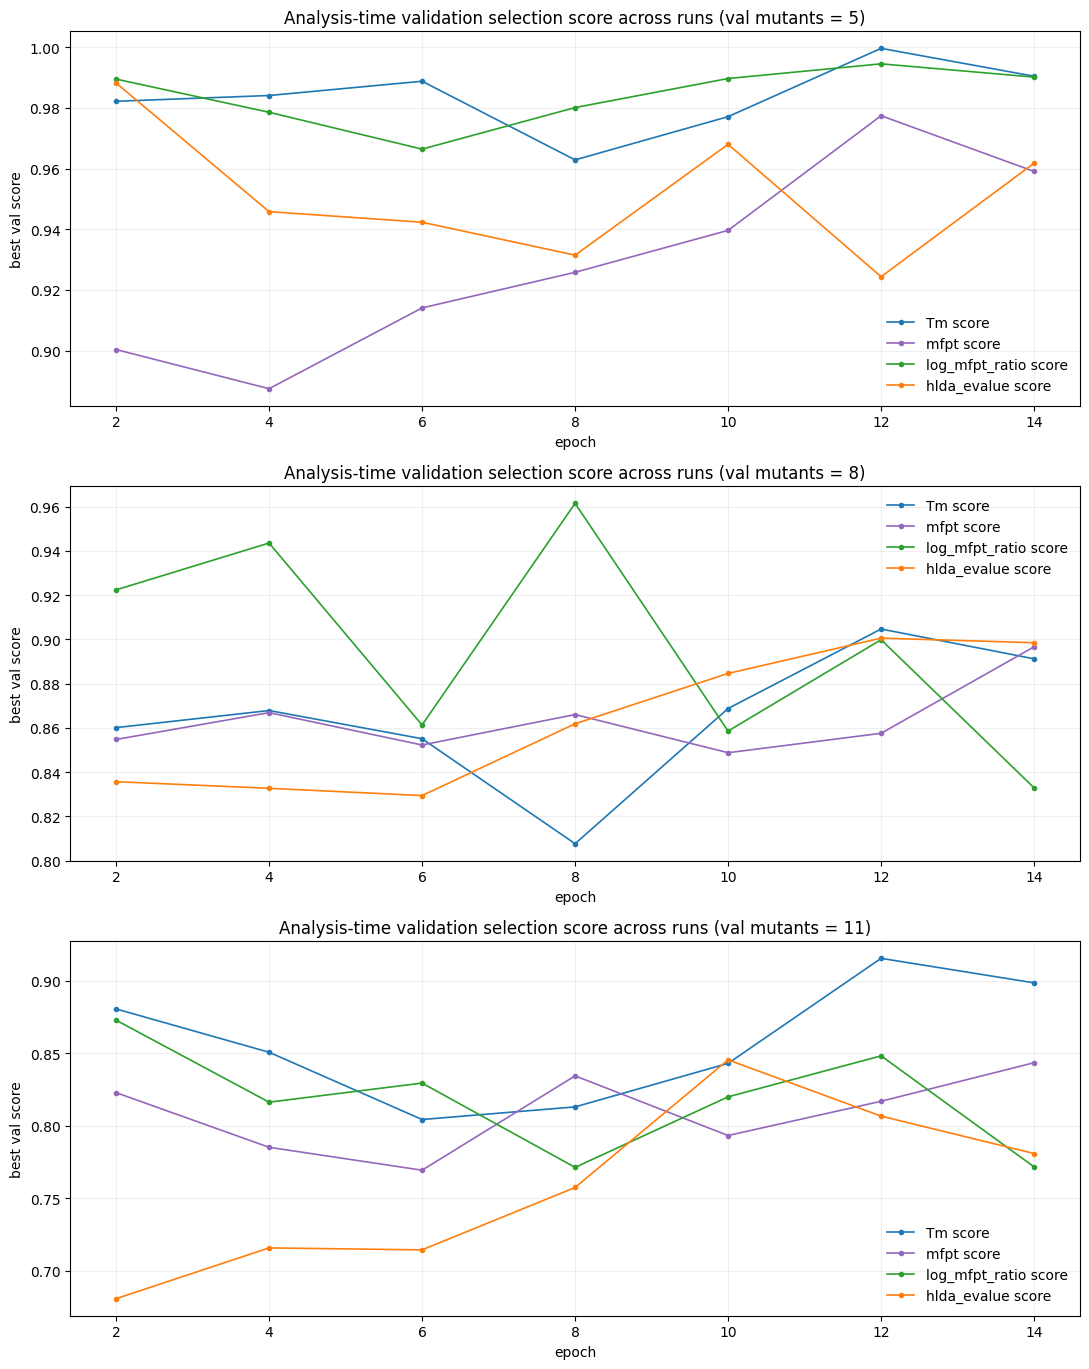

In [12]:
fig, axes = plt.subplots(len(analysis_val_mutant_counts), 1, figsize=(11, 4.6 * len(analysis_val_mutant_counts)), squeeze=False)
for ax, selected_analysis_val_mutants in zip(axes[:, 0], analysis_val_mutant_counts):
    for metric, color in [('Tm', 'tab:blue'), ('mfpt', 'tab:purple'), ('log_mfpt_ratio', 'tab:green'), ('hlda_evalue', 'tab:orange')]:
        sub = analysis_epoch_selection_df[
            (analysis_epoch_selection_df['metric'] == metric)
            & (analysis_epoch_selection_df['analysis_val_mutants'] == selected_analysis_val_mutants)
        ]
        best_per_epoch = sub.groupby('epoch', as_index=False)[['val_score', 'val_r2']].max().sort_values('epoch')
        ax.plot(best_per_epoch['epoch'], best_per_epoch['val_score'], marker='o', ms=3, lw=1.2, color=color, label=f'{metric} score')
    ax.set_xlabel('epoch')
    ax.set_ylabel('best val score')
    ax.set_title(f'Analysis-time validation selection score across runs (val mutants = {selected_analysis_val_mutants})')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()



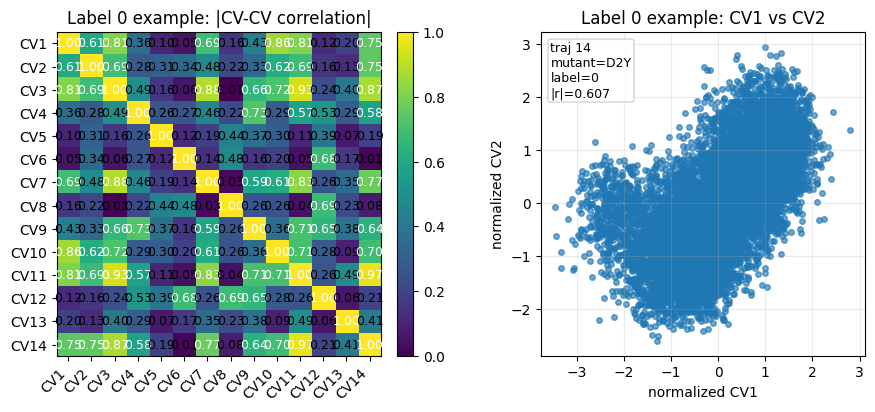

saved: ../results/chignolin_edge_transformer_cv/chignolin_val_single_label0_cv_view.png


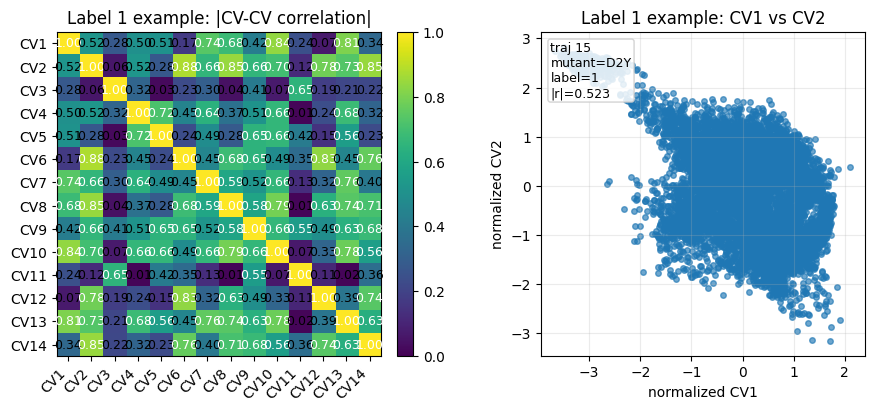

saved: ../results/chignolin_edge_transformer_cv/chignolin_val_single_label1_cv_view.png


In [13]:
first_row = analysis_global_selection_df.iloc[0]
split_payload = build_run_split_payload(int(first_row['run_seed']))
frame_cv_df = cv_frame_df_from_split(split_payload['val_x'], split_payload['val_samples_df'])
cv_cols = [c for c in frame_cv_df.columns if c.startswith('CV')]
assert len(cv_cols) >= 2
c1, c2 = cv_cols[0], cv_cols[1]

traj_label_df = split_payload['val_samples_df'][['traj_id']].drop_duplicates()
traj_label_df['label'] = [int(labels[int(tid)].item()) for tid in traj_label_df['traj_id']]
traj_to_mutant = split_payload['val_samples_df'][['traj_id', 'mutant']].drop_duplicates().reset_index(drop=True)
traj_label_df = traj_label_df.merge(traj_to_mutant, on='traj_id', how='left')

label0_traj = int(traj_label_df.loc[traj_label_df['label'] == 0, 'traj_id'].iloc[0])
label1_traj = int(traj_label_df.loc[traj_label_df['label'] == 1, 'traj_id'].iloc[0])

def normalize_pair(sub, xcol, ycol):
    x = sub[xcol].to_numpy(dtype=float)
    y = sub[ycol].to_numpy(dtype=float)
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return x, y

def plot_one_traj(traj_id, out_name, panel_title):
    sub = frame_cv_df[frame_cv_df['traj_id'] == int(traj_id)].reset_index(drop=True)
    row = traj_label_df[traj_label_df['traj_id'] == int(traj_id)].iloc[0]
    corr = np.abs(sub[cv_cols].corr(method='pearson').to_numpy(dtype=float))
    r = abs(float(sub[c1].corr(sub[c2], method='pearson')))
    x, y = normalize_pair(sub, c1, c2)

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
    im = axes[0].imshow(corr, vmin=0.0, vmax=1.0, cmap='viridis')
    axes[0].set_xticks(range(len(cv_cols)))
    axes[0].set_yticks(range(len(cv_cols)))
    axes[0].set_xticklabels(cv_cols, rotation=45, ha='right')
    axes[0].set_yticklabels(cv_cols)
    axes[0].set_title(f'{panel_title}: |CV-CV correlation|')
    for i in range(len(cv_cols)):
        for j in range(len(cv_cols)):
            axes[0].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9, color='white' if corr[i, j] > 0.55 else 'black')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].scatter(x, y, color='tab:blue', alpha=0.65, s=16)
    axes[1].set_title(f'{panel_title}: {c1} vs {c2}')
    axes[1].text(
        0.03, 0.97,
        f'traj {traj_id}\nmutant={row["mutant"]}\nlabel={int(row["label"])}\n|r|={r:.3f}',
        transform=axes[1].transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    axes[1].set_xlabel(f'normalized {c1}')
    axes[1].set_ylabel(f'normalized {c2}')
    axes[1].grid(alpha=0.25)
    axes[1].set_box_aspect(1)

    fig.tight_layout()
    out_path = run_dir / out_name
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', out_path)

plot_one_traj(label0_traj, 'chignolin_val_single_label0_cv_view.png', 'Label 0 example')
plot_one_traj(label1_traj, 'chignolin_val_single_label1_cv_view.png', 'Label 1 example')



### Correlations 
Here we expect to see a correlation emerging between the "naturally" occuring bottleneck CVs and pre-computed metrics per mutant

In [14]:
analysis_weight_options = (
    (0.8, 0.2),
    (0.5, 0.5),
    (0.2, 0.8),
)
analysis_success_threshold = 0.5
metric_label_map = {
    'Tm': 'Tm',
    'mfpt': 'MFPT',
    'log_mfpt_ratio': 'log MFPT ratio',
    'hlda_evalue': 'HLDA eig',
}


def compact_p(p_value):
    if np.isnan(p_value):
        return 'nan'
    if p_value < 1e-3:
        return '<1e-3'
    return f'{p_value:.3f}'


from scipy import stats as scipy_stats

def corr_p_from_r(r_value, n_points):
    if np.isnan(r_value) or n_points is None or n_points < 3:
        return float('nan')
    if abs(r_value) >= 1.0:
        return 0.0
    denom = max(1e-12, 1.0 - float(r_value) ** 2)
    t_stat = abs(float(r_value)) * np.sqrt((n_points - 2) / denom)
    return float(2.0 * scipy_stats.t.sf(t_stat, df=n_points - 2))


def signif_stars(p_value):
    if np.isnan(p_value):
        return 'na'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def bootstrap_corr_ci(x, y, method='pearson', n_boot=2000, seed=0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    if n < 4:
        return (float('nan'), float('nan'))
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        yb = y[idx]
        try:
            if method == 'pearson':
                value = float(np.corrcoef(xb, yb)[0, 1])
            else:
                value = float(scipy_stats.spearmanr(xb, yb).statistic)
        except Exception:
            value = float('nan')
        if np.isfinite(value):
            values.append(value)
    if len(values) < max(50, n_boot // 10):
        return (float('nan'), float('nan'))
    return tuple(np.quantile(values, [0.025, 0.975]))


def leave_one_out_min_abs_corr(x, y, method='pearson'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    if n < 4:
        return float('nan')
    values = []
    for drop_idx in range(n):
        mask = np.ones(n, dtype=bool)
        mask[drop_idx] = False
        try:
            if method == 'pearson':
                value = float(np.corrcoef(x[mask], y[mask])[0, 1])
            else:
                value = float(scipy_stats.spearmanr(x[mask], y[mask]).statistic)
        except Exception:
            value = float('nan')
        values.append(abs(value) if np.isfinite(value) else float('nan'))
    finite_values = [value for value in values if np.isfinite(value)]
    return min(finite_values) if finite_values else float('nan')


def evaluate_selected_row_support(row, seed_offset=0):
    payload = analysis_cache[(int(row['run_idx']), int(row['analysis_val_mutants']), int(row['epoch']))]
    metric = str(row['metric'])
    cv = str(row['cv'])
    test_points = payload['test_merged'][[cv, metric, 'mutant']].dropna()
    x = test_points[cv].to_numpy(dtype=float)
    y = test_points[metric].to_numpy(dtype=float)
    n_points = int(len(test_points))
    pearson_r = float(row['test_pearson'])
    spearman_r = float(row['test_spearman'])
    pearson_p = corr_p_from_r(pearson_r, n_points)
    spearman_p = corr_p_from_r(spearman_r, n_points)
    pearson_ci_low, pearson_ci_high = bootstrap_corr_ci(x, y, method='pearson', seed=seed_offset)
    spearman_ci_low, spearman_ci_high = bootstrap_corr_ci(x, y, method='spearman', seed=seed_offset + 1)
    loo_min_abs_pearson = leave_one_out_min_abs_corr(x, y, method='pearson')
    loo_min_abs_spearman = leave_one_out_min_abs_corr(x, y, method='spearman')
    return {
        'test_n': n_points,
        'pearson_p': pearson_p,
        'spearman_p': spearman_p,
        'pearson_sig': signif_stars(pearson_p),
        'spearman_sig': signif_stars(spearman_p),
        'pearson_ci_low': pearson_ci_low,
        'pearson_ci_high': pearson_ci_high,
        'spearman_ci_low': spearman_ci_low,
        'spearman_ci_high': spearman_ci_high,
        'loo_min_abs_pearson': loo_min_abs_pearson,
        'loo_min_abs_spearman': loo_min_abs_spearman,
    }


def build_support_summary(report_df, analysis_val_mutants):
    selected = report_df[report_df['analysis_val_mutants'] == analysis_val_mutants].copy()
    rows = []
    for row_idx, (_, row) in enumerate(selected.sort_values(['run_idx', 'metric']).iterrows()):
        support = evaluate_selected_row_support(row, seed_offset=1000 + row_idx)
        rows.append({
            'run_idx': int(row['run_idx']),
            'metric': str(row['metric']),
            'cv': str(row['cv']),
            'summary_type': str(row['summary_type']),
            'test_n': support['test_n'],
            'test_pearson': float(row['test_pearson']),
            'pearson_p': support['pearson_p'],
            'pearson_sig': support['pearson_sig'],
            'pearson_ci': f"[{support['pearson_ci_low']:.2f}, {support['pearson_ci_high']:.2f}]" if np.isfinite(support['pearson_ci_low']) and np.isfinite(support['pearson_ci_high']) else 'nan',
            'pearson_loo_min_abs': support['loo_min_abs_pearson'],
            'test_spearman': float(row['test_spearman']),
            'spearman_p': support['spearman_p'],
            'spearman_sig': support['spearman_sig'],
            'spearman_ci': f"[{support['spearman_ci_low']:.2f}, {support['spearman_ci_high']:.2f}]" if np.isfinite(support['spearman_ci_low']) and np.isfinite(support['spearman_ci_high']) else 'nan',
            'spearman_loo_min_abs': support['loo_min_abs_spearman'],
        })
    return pd.DataFrame(rows)


def build_weighted_run_report(weight_pearson, weight_spearman):
    weighted_df = analysis_candidates_df.copy()
    weighted_df['val_score'] = (
        weight_pearson * weighted_df['val_pearson'].abs()
        + weight_spearman * weighted_df['val_spearman'].abs()
    )
    run_selection_df = (
        weighted_df
        .sort_values(
            ['analysis_val_mutants', 'run_idx', 'metric', 'val_score', 'test_pearson', 'test_spearman'],
            ascending=[True, True, True, False, False, False],
        )
        .groupby(['analysis_val_mutants', 'run_idx', 'metric'], as_index=False)
        .first()
    )
    run_selection_df['val_abs_pearson'] = run_selection_df['val_pearson'].abs()
    run_selection_df['val_abs_spearman'] = run_selection_df['val_spearman'].abs()
    run_selection_df['test_abs_pearson'] = run_selection_df['test_pearson'].abs()
    run_selection_df['test_abs_spearman'] = run_selection_df['test_spearman'].abs()
    run_selection_df['test_score'] = (
        weight_pearson * run_selection_df['test_abs_pearson']
        + weight_spearman * run_selection_df['test_abs_spearman']
    )
    run_selection_df['generalization_gap'] = run_selection_df['val_score'] - run_selection_df['test_score']
    run_selection_df['weight_label'] = f'P{weight_pearson:.1f}/S{weight_spearman:.1f}'
    return run_selection_df


def ensure_weighted_run_reports():
    global weighted_run_reports
    if 'weighted_run_reports' not in globals():
        weighted_run_reports = {
            f'P{wp:.1f}/S{ws:.1f}': build_weighted_run_report(wp, ws)
            for wp, ws in analysis_weight_options
        }
    return weighted_run_reports


def get_selected_report_df(weight_label):
    reports = ensure_weighted_run_reports()
    return reports[weight_label]


def get_selected_row(report_df, analysis_val_mutants, run_idx, metric):
    return report_df[
        (report_df['analysis_val_mutants'] == analysis_val_mutants)
        & (report_df['run_idx'] == run_idx)
        & (report_df['metric'] == metric)
    ].iloc[0]


def build_score_tables(report_df, analysis_val_mutants, metrics=None):
    metrics = analysis_metrics if metrics is None else metrics
    sub = report_df[report_df['analysis_val_mutants'] == analysis_val_mutants].copy()
    score_mat = (
        sub.pivot(index='run_idx', columns='metric', values='test_score')
        .reindex(index=sorted(sub['run_idx'].unique()), columns=metrics)
    )
    pearson_mat = (
        sub.pivot(index='run_idx', columns='metric', values='test_abs_pearson')
        .reindex(index=score_mat.index, columns=metrics)
    )
    spearman_mat = (
        sub.pivot(index='run_idx', columns='metric', values='test_abs_spearman')
        .reindex(index=score_mat.index, columns=metrics)
    )
    hit_rate = (score_mat >= analysis_success_threshold).mean(axis=0)
    test_mutant_count = int(sub['analysis_test_mutants'].iloc[0])
    return sub, score_mat, pearson_mat, spearman_mat, hit_rate, test_mutant_count


def render_score_matrix(report_df, weight_label, analysis_val_mutants, title_prefix='Test score'):
    metrics = analysis_metrics
    metric_labels = [metric_label_map.get(metric, metric) for metric in metrics]
    sub, score_mat, pearson_mat, spearman_mat, hit_rate, test_mutant_count = build_score_tables(
        report_df,
        analysis_val_mutants,
        metrics=metrics,
    )
    print('Metric labels:', ', '.join(f'{short}={full}' for short, full in zip(metric_labels, metrics)))
    print(f'{weight_label}, val mutants = {analysis_val_mutants}, test mutants = {test_mutant_count}')

    fig, axes = plt.subplots(1, 2, figsize=(17.8, 5.6), gridspec_kw={'width_ratios': [6.6, 1.8]})
    im = axes[0].imshow(score_mat.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap='viridis', aspect='auto')
    axes[0].set_xticks(range(len(metrics)))
    axes[0].set_xticklabels(metric_labels, rotation=0, ha='center', fontsize=11)
    axes[0].set_yticks(range(len(score_mat.index)))
    axes[0].set_yticklabels([f'run {int(v)}' for v in score_mat.index])
    axes[0].set_title(
        f'{title_prefix} {weight_label}, val mutants = {analysis_val_mutants}, test mutants = {test_mutant_count}'
    )
    for i in range(score_mat.shape[0]):
        for j in range(score_mat.shape[1]):
            score = float(score_mat.iloc[i, j])
            rp = float(pearson_mat.iloc[i, j])
            rs = float(spearman_mat.iloc[i, j])
            row = get_selected_row(sub, analysis_val_mutants, score_mat.index[i], metrics[j])
            payload = analysis_cache[(int(row['run_idx']), int(row['analysis_val_mutants']), int(row['epoch']))]
            test_points = payload['test_merged'][[str(row['cv']), metrics[j], 'mutant']].dropna()
            n_points = int(len(test_points))
            rp_p = corr_p_from_r(rp, n_points)
            rs_p = corr_p_from_r(rs, n_points)
            axes[0].text(
                j,
                i,
                f'{score:.2f} r={rp:.2f} p={compact_p(rp_p)} ρ={rs:.2f} p={compact_p(rs_p)}',
                ha='center',
                va='center',
                fontsize=9,
                color='white' if score > 0.55 else 'black',
            )
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].bar(range(len(metrics)), hit_rate.to_numpy(dtype=float), color='tab:blue', alpha=0.85, width=0.62)
    axes[1].axhline(1.0, color='black', linewidth=0.8)
    axes[1].set_xticks(range(len(metrics)))
    axes[1].set_xticklabels(metric_labels, rotation=0, ha='center', fontsize=11)
    axes[1].set_ylim(0.0, 1.05)
    axes[1].set_ylabel('fraction of runs above threshold')
    axes[1].set_title(f'Hit rate, test mutants = {test_mutant_count} score ≥ {analysis_success_threshold:.2f}')
    axes[1].grid(alpha=0.2, axis='y')
    for i, value in enumerate(hit_rate.to_numpy(dtype=float)):
        axes[1].text(i, value + 0.03, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


weighted_run_reports = ensure_weighted_run_reports()
print('weight options:', analysis_weight_options)
print('compact success threshold on test score =', analysis_success_threshold)


weight options: ((0.8, 0.2), (0.5, 0.5), (0.2, 0.8))
compact success threshold on test score = 0.5


In [23]:
summary_cols = [
    'analysis_val_mutants', 'analysis_test_mutants', 'run_idx', 'metric', 'epoch', 'cv', 'summary_type',
    'val_score', 'val_r2', 'val_spearman', 'val_pearson',
    'test_r2', 'test_spearman', 'test_pearson'
]
selected_report_df = get_selected_report_df(selected_weight_label)
print('Pinned per-run selected checkpoints')
selected_report_df[
    selected_report_df['analysis_val_mutants'] == selected_analysis_val_mutants
][summary_cols].sort_values(['run_idx', 'metric']).round(3)


Pinned per-run selected checkpoints


,analysis_val_mutants,analysis_test_mutants,run_idx,metric,epoch,cv,summary_type,val_score,val_r2,val_spearman,val_pearson,test_r2,test_spearman,test_pearson
80,11,4,1,Tm,6,CV13_median,median,0.813,0.630,-0.818,-0.794,0.147,0.8,0.383
81,11,4,1,hlda_evalue,4,CV12_mean,mean,0.806,0.470,-0.836,-0.686,0.015,0.2,0.122
82,11,4,1,log_mfpt_ratio,4,CV6_mean,mean,0.804,0.506,-0.827,-0.711,0.002,-0.2,-0.048
83,11,4,1,mfpt,4,CV6_mean,mean,0.760,0.243,-0.827,-0.493,0.074,-0.2,0.273
84,11,4,2,Tm,4,CV8_mean,mean,0.768,0.613,-0.764,-0.783,0.704,-0.4,-0.839
85,11,4,2,hlda_evalue,14,CV8_mean,mean,0.785,0.577,-0.791,-0.760,0.456,-0.8,-0.675
86,11,4,2,log_mfpt_ratio,12,CV8_mean,mean,0.649,0.308,-0.673,-0.555,0.821,-1.0,-0.906
87,11,4,2,mfpt,12,CV8_mean,mean,0.551,0.004,-0.673,-0.066,0.989,-1.0,-0.994
88,11,4,3,Tm,12,CV7_median,median,0.767,0.552,0.773,0.743,0.015,0.2,0.122
89,11,4,3,hlda_evalue,10,CV6_mean,mean,0.792,0.425,0.827,0.652,0.219,0.2,0.468


Selected best-per-run overlay scatter is shown below the pinned test score matrix.


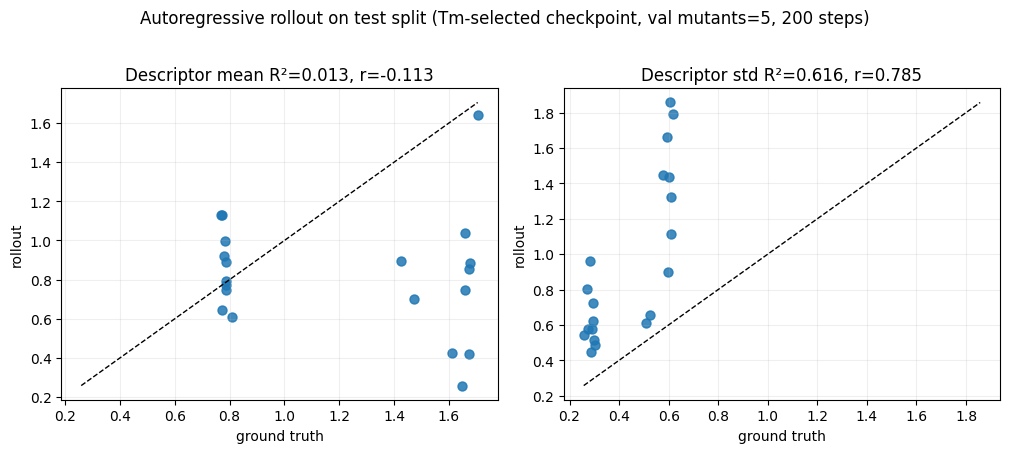

val mutants = 5 mean descriptor MSE = 1.7553055241703988


,traj_id,mutant,steps,true_mean,pred_mean,true_std,pred_std,descriptor_mse
0,12,D2R,200,0.780056,0.920904,0.290337,0.576766,0.369435
1,13,D2R,200,1.704754,1.642616,0.618514,1.794204,2.477482
2,18,E4G,200,0.785365,0.775068,0.287978,0.445078,0.134137
3,19,E4G,200,1.610798,0.423274,0.579195,1.448237,4.461298
4,22,E4Y,200,0.785656,0.791003,0.297156,0.516809,0.327115


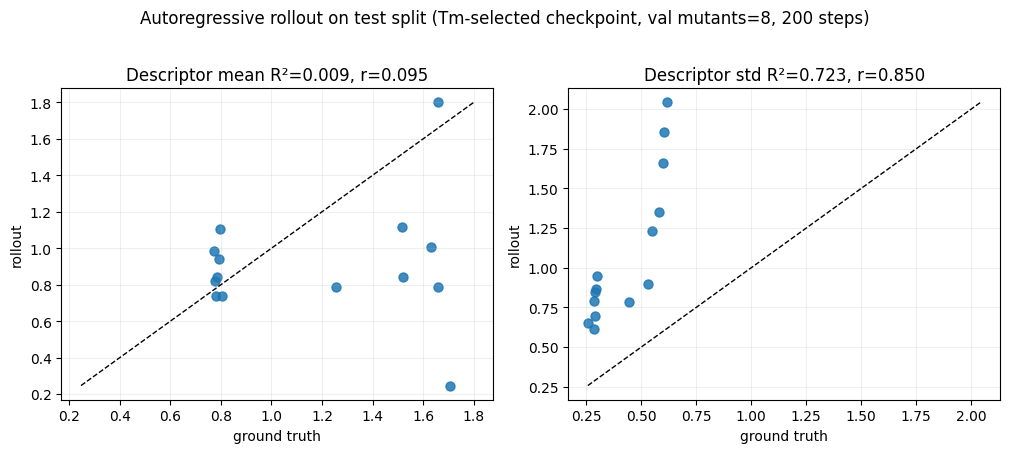

val mutants = 8 mean descriptor MSE = 1.7650874512536185


,traj_id,mutant,steps,true_mean,pred_mean,true_std,pred_std,descriptor_mse
0,6,D2K,200,0.795695,1.108363,0.285204,0.615914,0.532741
1,7,D2K,200,1.629382,1.004813,0.580795,1.352751,2.660230
2,8,D2M,200,0.778583,0.823237,0.286714,0.789000,0.582350
3,9,D2M,200,1.253792,0.787392,0.446413,0.785855,0.971524
4,12,D2R,200,0.780056,0.740729,0.290337,0.848105,0.746326


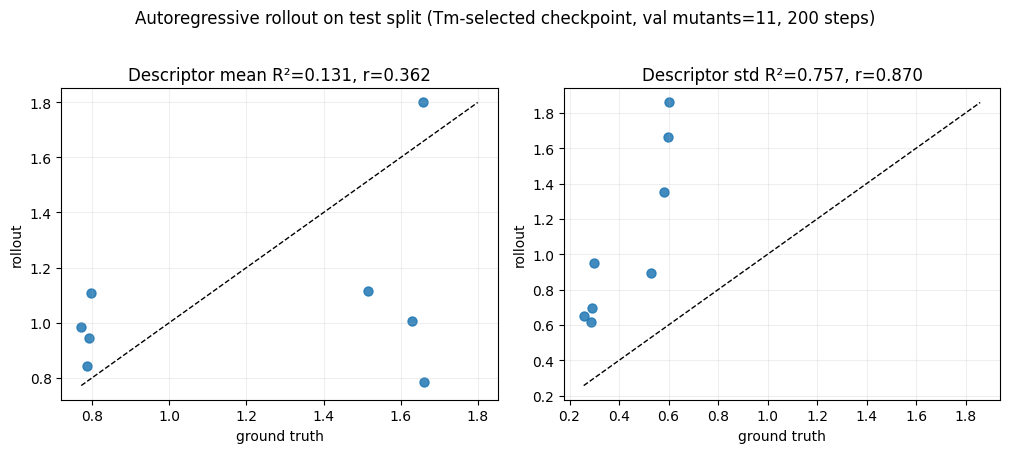

val mutants = 11 mean descriptor MSE = 1.5246188417077065


,traj_id,mutant,steps,true_mean,pred_mean,true_std,pred_std,descriptor_mse
0,6,D2K,200,0.795695,1.108363,0.285204,0.615914,0.532741
1,7,D2K,200,1.629382,1.004813,0.580795,1.352751,2.660230
2,22,E4Y,200,0.785656,0.843034,0.297156,0.949744,0.878745
3,23,E4Y,200,1.657294,1.799430,0.597284,1.661410,1.584419
4,44,T7Q,200,0.771569,0.985313,0.257336,0.650798,0.478864


In [33]:
# Autoregressive descriptor rollout: compare ground-truth vs predicted descriptor mean and std.
rollout_metric = 'Tm'
rollout_split = 'test'
rollout_steps = 200

for selected_analysis_val_mutants in analysis_val_mutant_counts:
    row = analysis_global_selection_df[
        (analysis_global_selection_df['analysis_val_mutants'] == selected_analysis_val_mutants)
        & (analysis_global_selection_df['metric'] == rollout_metric)
    ].iloc[0]
    payload = analysis_cache[(int(row['run_idx']), int(row['analysis_val_mutants']), int(row['epoch']))]
    split_payload = payload['split_payload']
    model = ChignolinEdgeTransformerCV(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        cv_count=CVs,
        edge_layers=edge_layers,
        heads=heads,
        dropout=dropout,
    ).to(device)
    ckpt = torch.load(row['checkpoint_path'], map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    def rollout_descriptor_traj(model, xt, history, steps, x_mean, x_std, dv_mean, dv_std):
        xt = clip_traj(xt, frames_per_traj)
        start_t = max(history - 1, 1)
        frames = [xt[i].clone() for i in range(start_t + 1)]
        steps = min(int(steps), int(xt.shape[0] - 1 - start_t))
        for _ in range(steps):
            cur_t = len(frames) - 1
            hist_raw = torch.stack(frames[cur_t - history + 1: cur_t + 1], dim=0)
            xh = ((hist_raw - x_mean) / x_std).unsqueeze(0).to(device)
            dv_pred, _, _, _ = model(xh)
            dv_pred = dv_pred.squeeze(0).detach().cpu() * dv_std + dv_mean
            cur_vel = frames[cur_t] - frames[cur_t - 1]
            next_vel = cur_vel + dv_pred
            next_x = frames[cur_t] + next_vel
            frames.append(next_x)
        pred = torch.stack(frames, dim=0)
        return pred, start_t, steps

    traj_ids = split_payload[f'{rollout_split}_ids']
    rows = []
    for tid in traj_ids:
        xt, _ = traj_slice(x_all, time_all, offsets, int(tid))
        pred_traj, start_t, used_steps = rollout_descriptor_traj(
            model, xt, history, rollout_steps,
            split_payload['x_mean'], split_payload['x_std'],
            split_payload['dv_mean'], split_payload['dv_std'],
        )
        true_final = clip_traj(xt, frames_per_traj)[start_t + used_steps]
        pred_final = pred_traj[-1]
        rows.append({
            'traj_id': int(tid),
            'mutant': str(mutants[int(tid)]),
            'steps': int(used_steps),
            'true_mean': float(true_final.mean()),
            'pred_mean': float(pred_final.mean()),
            'true_std': float(true_final.std()),
            'pred_std': float(pred_final.std()),
            'descriptor_mse': float(torch.mean((pred_final - true_final) ** 2).item()),
        })

    rollout_df = pd.DataFrame(rows)
    mean_r2 = fit_r2(rollout_df['pred_mean'].to_numpy(), rollout_df['true_mean'].to_numpy())
    std_r2 = fit_r2(rollout_df['pred_std'].to_numpy(), rollout_df['true_std'].to_numpy())
    mean_r = float(rollout_df['pred_mean'].corr(rollout_df['true_mean'], method='pearson'))
    std_r = float(rollout_df['pred_std'].corr(rollout_df['true_std'], method='pearson'))

    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4))
    for ax, xcol, ycol, title, score_r2, score_r in [
        (axes[0], 'true_mean', 'pred_mean', 'Descriptor mean', mean_r2, mean_r),
        (axes[1], 'true_std', 'pred_std', 'Descriptor std', std_r2, std_r),
    ]:
        x = rollout_df[xcol].to_numpy(dtype=float)
        y = rollout_df[ycol].to_numpy(dtype=float)
        ax.scatter(x, y, s=42, alpha=0.85)
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1.0)
        ax.set_title(f'{title} R²={score_r2:.3f}, r={score_r:.3f}')
        ax.set_xlabel('ground truth')
        ax.set_ylabel('rollout')
        ax.grid(alpha=0.2)

    fig.suptitle(
        f'Autoregressive rollout on {rollout_split} split ({rollout_metric}-selected checkpoint, val mutants={selected_analysis_val_mutants}, {rollout_steps} steps)',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    print('val mutants =', selected_analysis_val_mutants, 'mean descriptor MSE =', float(rollout_df['descriptor_mse'].mean()))
    display(rollout_df.head())



Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.2/S0.8, val mutants = 11, test mutants = 4


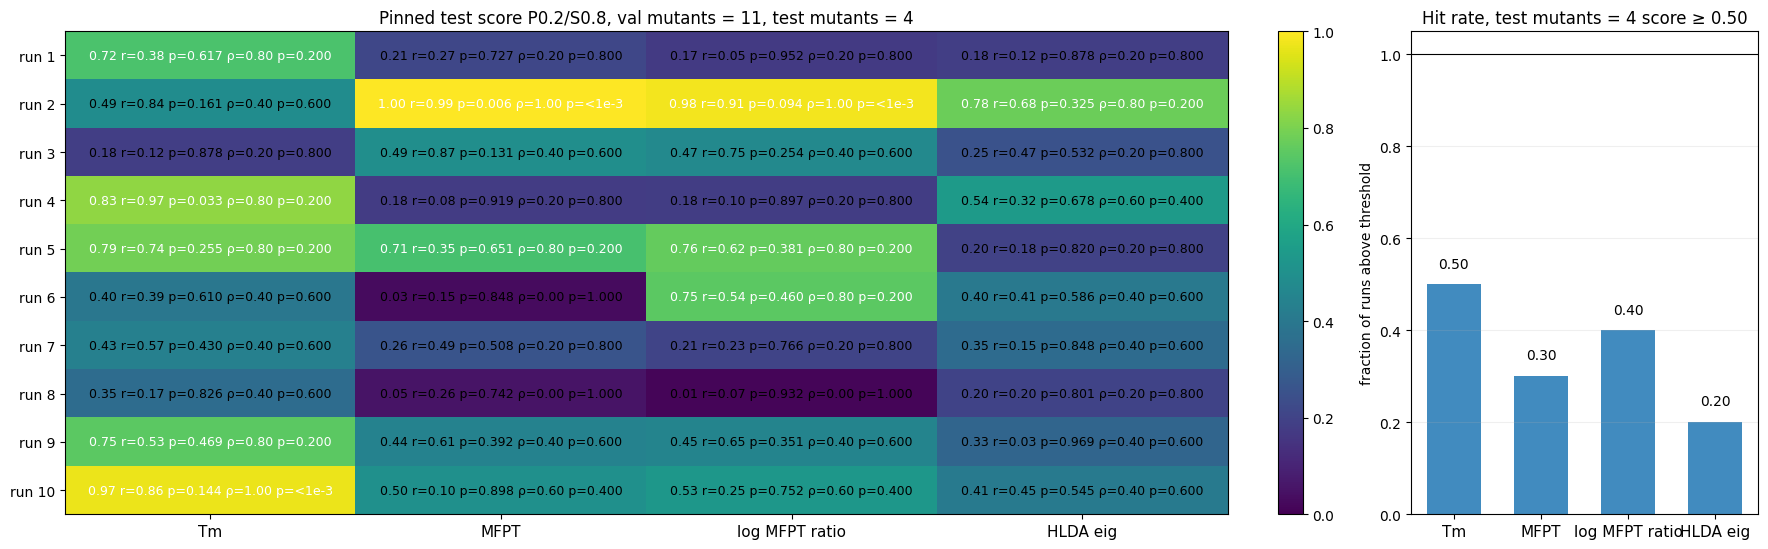

In [38]:
selected_report_df = get_selected_report_df(selected_weight_label)
render_score_matrix(
    selected_report_df,
    selected_weight_label,
    selected_analysis_val_mutants,
    title_prefix='Pinned test score',
)


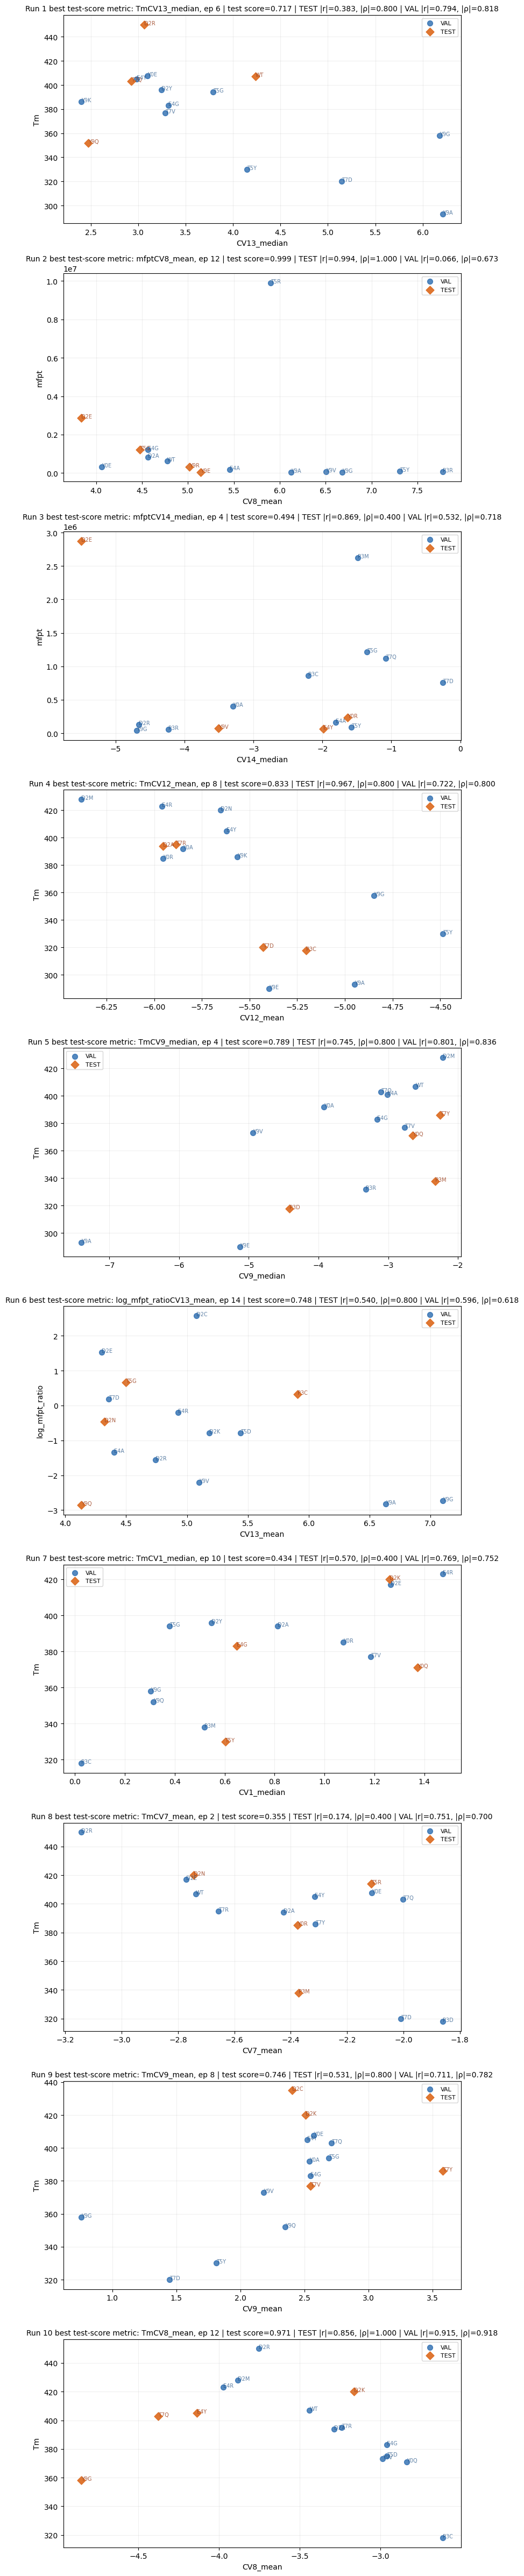

In [39]:
selected_report_df = get_selected_report_df(selected_weight_label)
sub = selected_report_df[selected_report_df['analysis_val_mutants'] == selected_analysis_val_mutants].copy()
score_mat = (
    sub.pivot(index='run_idx', columns='metric', values='test_score')
    .reindex(columns=analysis_metrics)
)

run_best_rows = []
for run_idx in score_mat.index:
    run_scores = score_mat.loc[run_idx].dropna()
    if run_scores.empty:
        continue
    best_metric = run_scores.astype(float).idxmax()
    run_best_rows.append(get_selected_row(selected_report_df, selected_analysis_val_mutants, int(run_idx), best_metric))
run_best_df = pd.DataFrame(run_best_rows).sort_values('run_idx').reset_index(drop=True)

fig, axes = plt.subplots(len(run_best_df), 1, figsize=(8.4, 4.8 * len(run_best_df)), squeeze=False)
for plot_i, (_, row) in enumerate(run_best_df.iterrows()):
    ax = axes[plot_i, 0]
    metric = row['metric']
    payload = analysis_cache[(int(row['run_idx']), int(row['analysis_val_mutants']), int(row['epoch']))]
    cv = str(row['cv'])
    val_sub = payload['val_merged'][[cv, metric, 'mutant']].dropna().copy()
    test_sub = payload['test_merged'][[cv, metric, 'mutant']].dropna().copy()

    if len(val_sub):
        ax.scatter(val_sub[cv], val_sub[metric], s=50, alpha=0.8, color='#2b6cb0', label='VAL')
    if len(test_sub):
        ax.scatter(test_sub[cv], test_sub[metric], s=58, alpha=0.92, color='#dd6b20', marker='D', label='TEST')

    for _, rr in val_sub.iterrows():
        ax.text(rr[cv], rr[metric], str(rr['mutant']), fontsize=7, alpha=0.72, color='#1f4f82')
    for _, rr in test_sub.iterrows():
        ax.text(rr[cv], rr[metric], str(rr['mutant']), fontsize=7, alpha=0.86, color='#9c4221')

    ax.set_title(
        f'Run {int(row["run_idx"])} best test-score metric: {metric}'
        f'{cv}, ep {int(row["epoch"])} | '
        f'test score={float(row["test_score"]):.3f} | '
        f'TEST |r|={abs(row["test_pearson"]):.3f}, |ρ|={abs(row["test_spearman"]):.3f} | '
        f'VAL |r|={abs(row["val_pearson"]):.3f}, |ρ|={abs(row["val_spearman"]):.3f}',
        fontsize=10,
    )
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()



In [40]:
selected_report_df = get_selected_report_df(selected_weight_label)
support_summary_df = build_support_summary(selected_report_df, selected_analysis_val_mutants)
print('Pinned support summary from selected test points')
support_summary_df.sort_values(['metric', 'run_idx']).round(3)



/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/tmp/ipykernel_2198729/1412979989.py:63: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  value = float(scipy_stats.spearmanr(xb, yb).statistic)


Pinned support summary from selected test points


,run_idx,metric,cv,summary_type,test_n,test_pearson,pearson_p,pearson_sig,pearson_ci,pearson_loo_min_abs,test_spearman,spearman_p,spearman_sig,spearman_ci,spearman_loo_min_abs
0,1,Tm,CV13_median,median,4,0.383,0.617,ns,"[-1.00, 1.00]",0.348,0.8,0.2,ns,"[-1.00, 1.00]",0.5
4,2,Tm,CV8_mean,mean,4,-0.839,0.161,ns,"[-1.00, 1.00]",0.585,-0.4,0.6,ns,"[-1.00, 1.00]",0.5
8,3,Tm,CV7_median,median,4,0.122,0.878,ns,"[-1.00, 1.00]",0.104,0.2,0.8,ns,"[-1.00, 1.00]",0.5
12,4,Tm,CV12_mean,mean,4,-0.967,0.033,*,"[-1.00, 1.00]",0.952,-0.8,0.2,ns,"[-1.00, 1.00]",0.5
16,5,Tm,CV9_median,median,4,0.745,0.255,ns,"[-1.00, 1.00]",0.046,0.8,0.2,ns,"[-1.00, 1.00]",0.5
20,6,Tm,CV14_mean,mean,4,-0.390,0.610,ns,"[-1.00, 1.00]",0.282,-0.4,0.6,ns,"[-1.00, 1.00]",0.5
24,7,Tm,CV1_median,median,4,0.570,0.430,ns,"[-1.00, 1.00]",0.143,0.4,0.6,ns,"[-1.00, 1.00]",0.5
28,8,Tm,CV7_mean,mean,4,-0.174,0.826,ns,"[-1.00, 1.00]",0.169,-0.4,0.6,ns,"[-1.00, 1.00]",0.5
32,9,Tm,CV9_mean,mean,4,-0.531,0.469,ns,"[-1.00, 1.00]",0.348,-0.8,0.2,ns,"[-1.00, 1.00]",0.5
36,10,Tm,CV8_mean,mean,4,0.856,0.144,ns,"[0.82, 1.00]",0.876,1.0,0.0,***,"[1.00, 1.00]",1.0


Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.8/S0.2, val mutants = 5, test mutants = 10


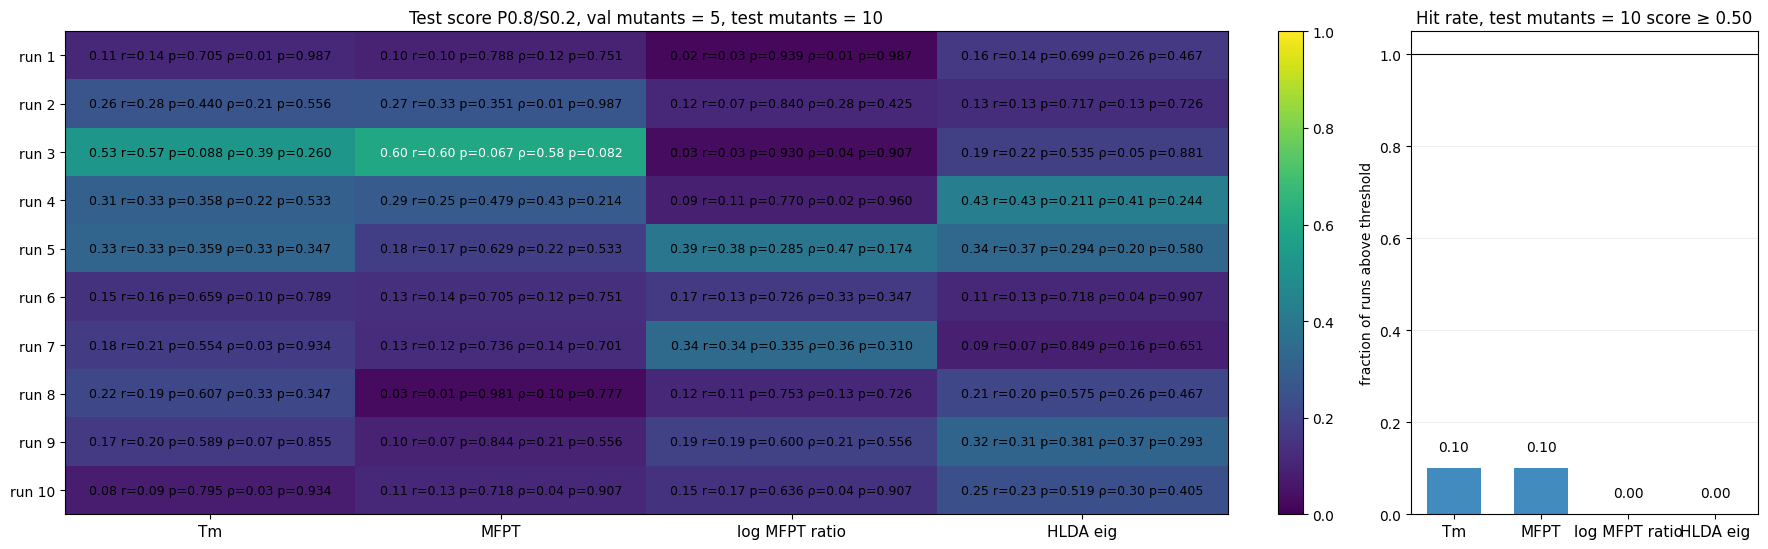

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.8/S0.2, val mutants = 8, test mutants = 7


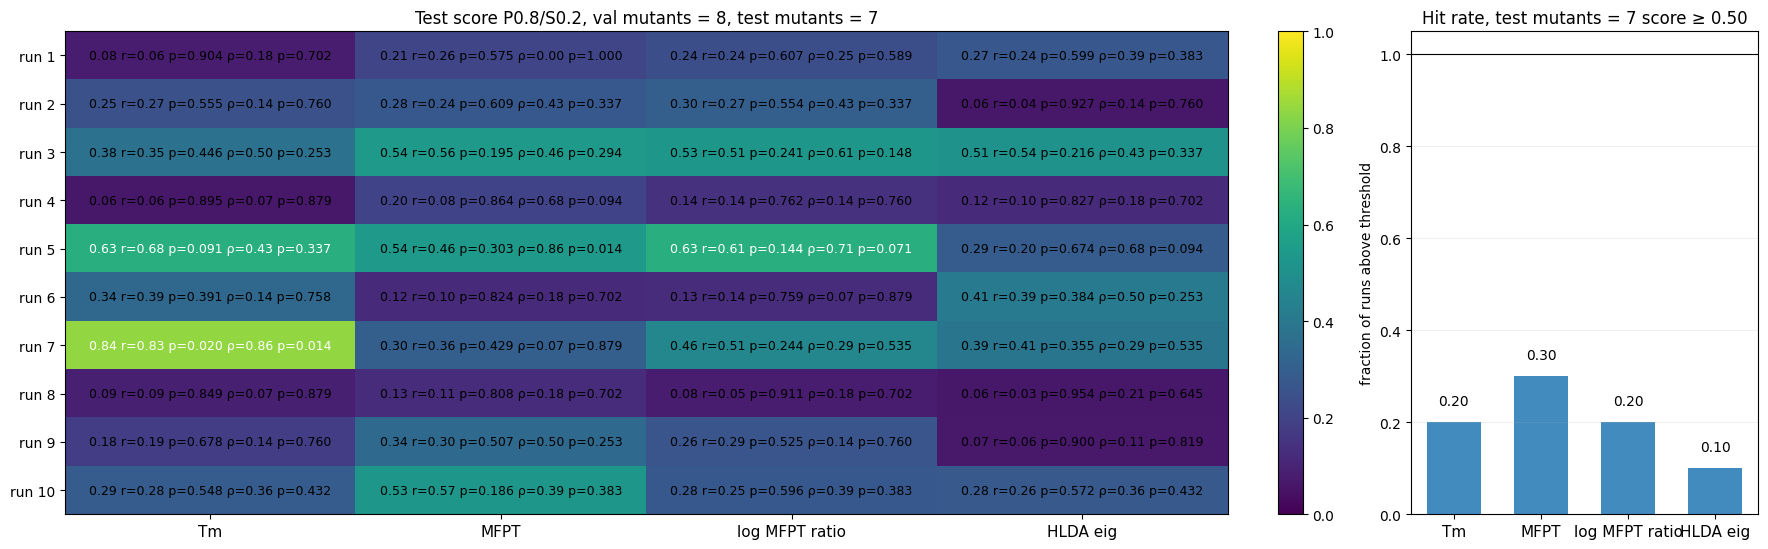

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.8/S0.2, val mutants = 11, test mutants = 4


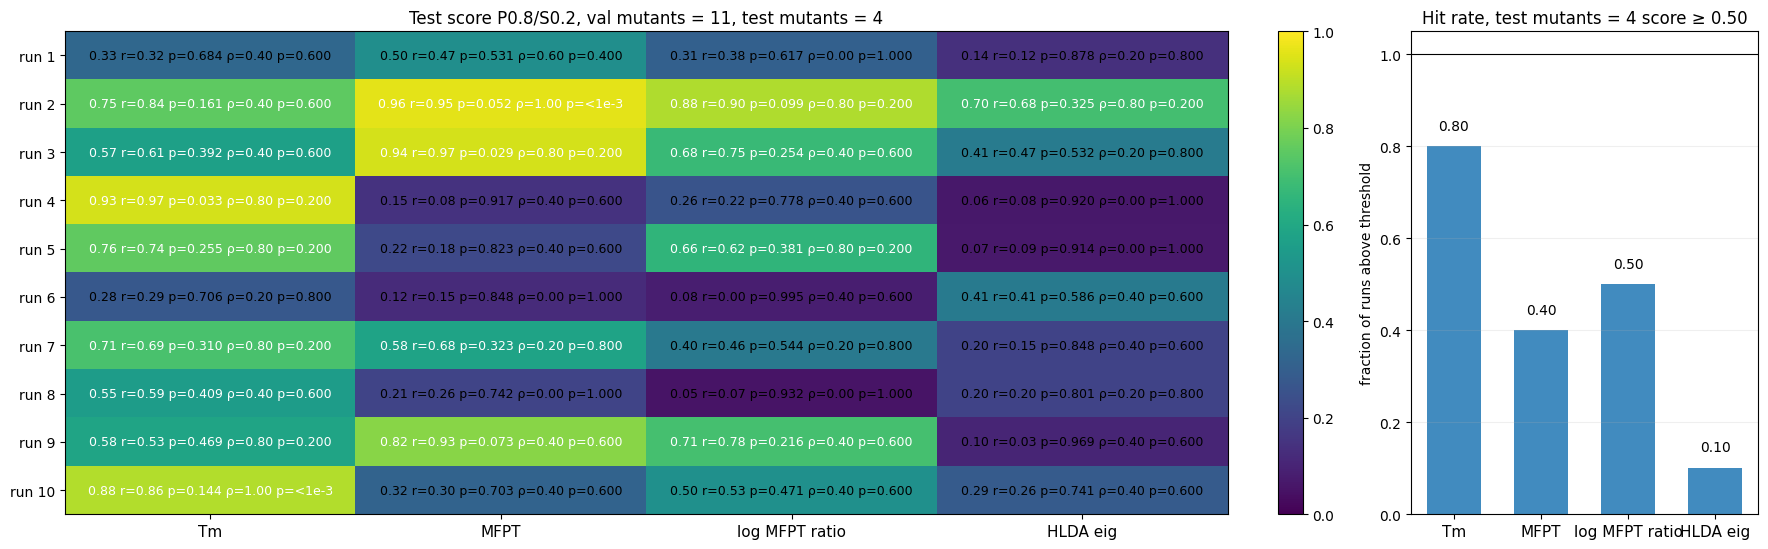

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.5/S0.5, val mutants = 5, test mutants = 10


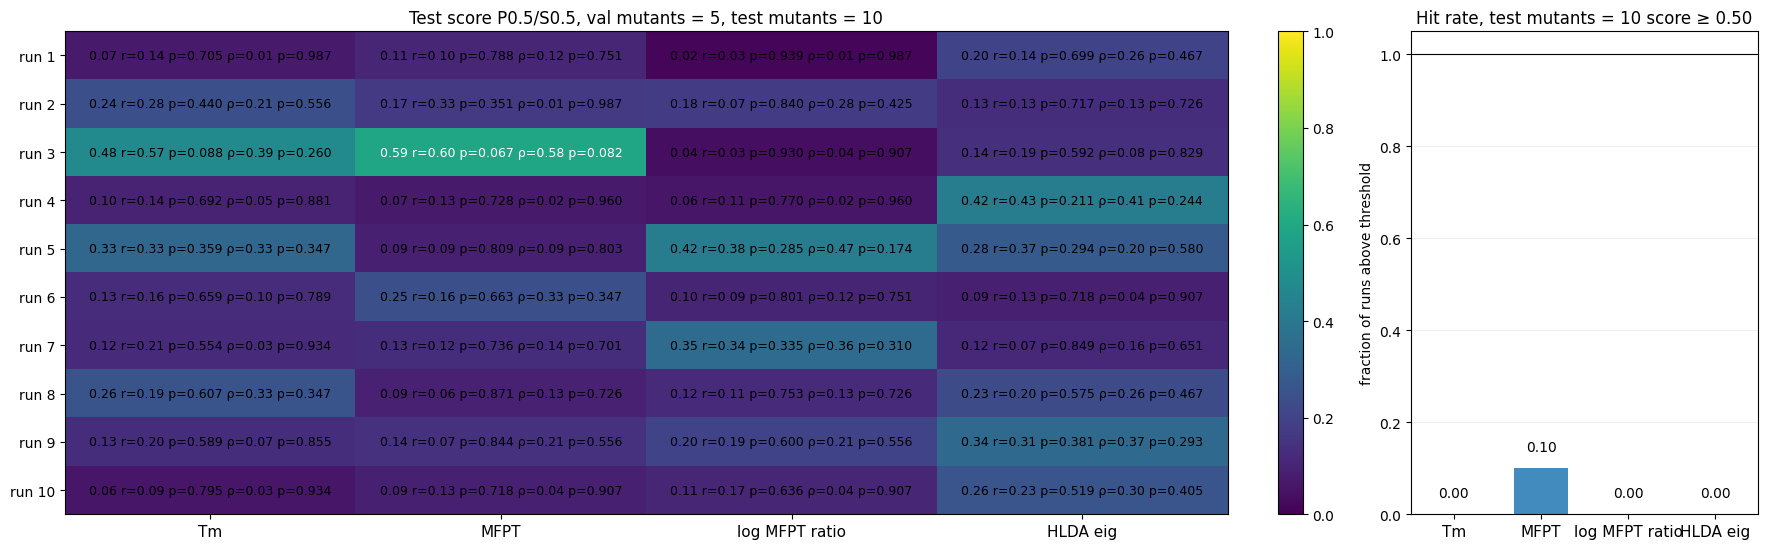

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.5/S0.5, val mutants = 8, test mutants = 7


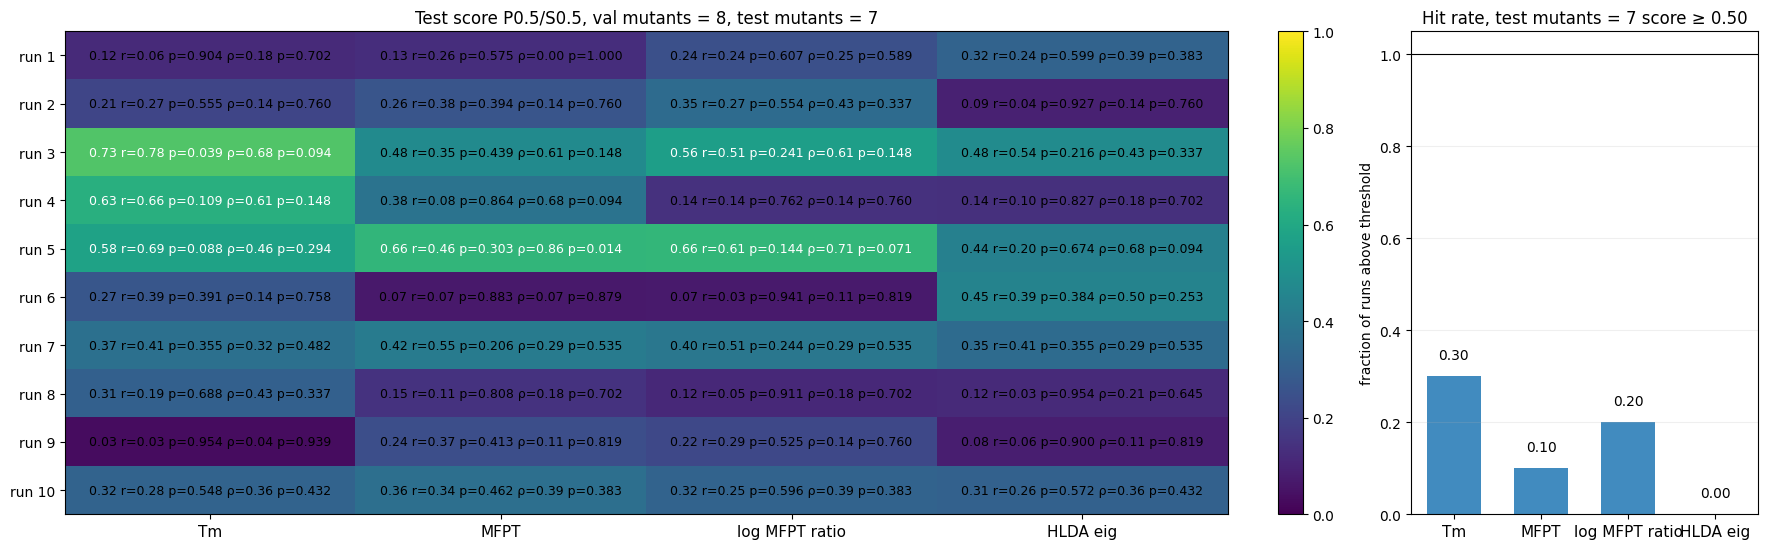

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.5/S0.5, val mutants = 11, test mutants = 4


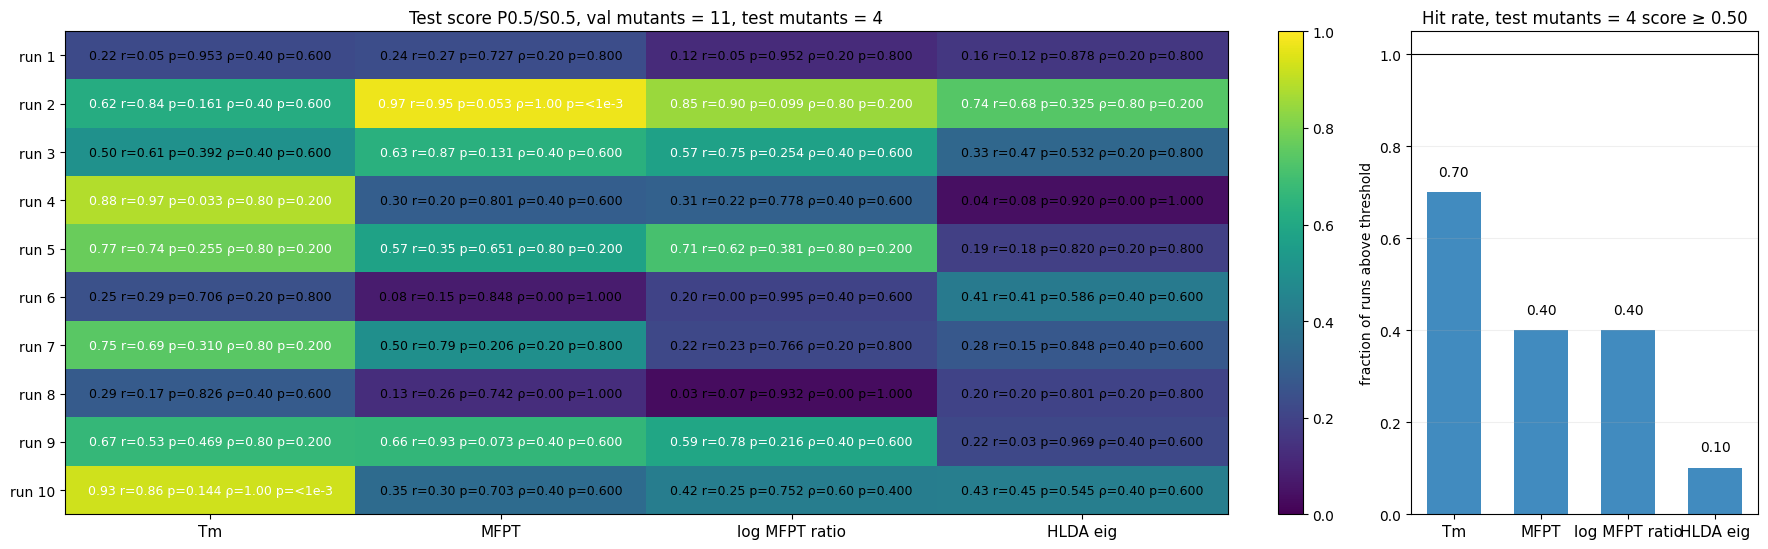

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.2/S0.8, val mutants = 5, test mutants = 10


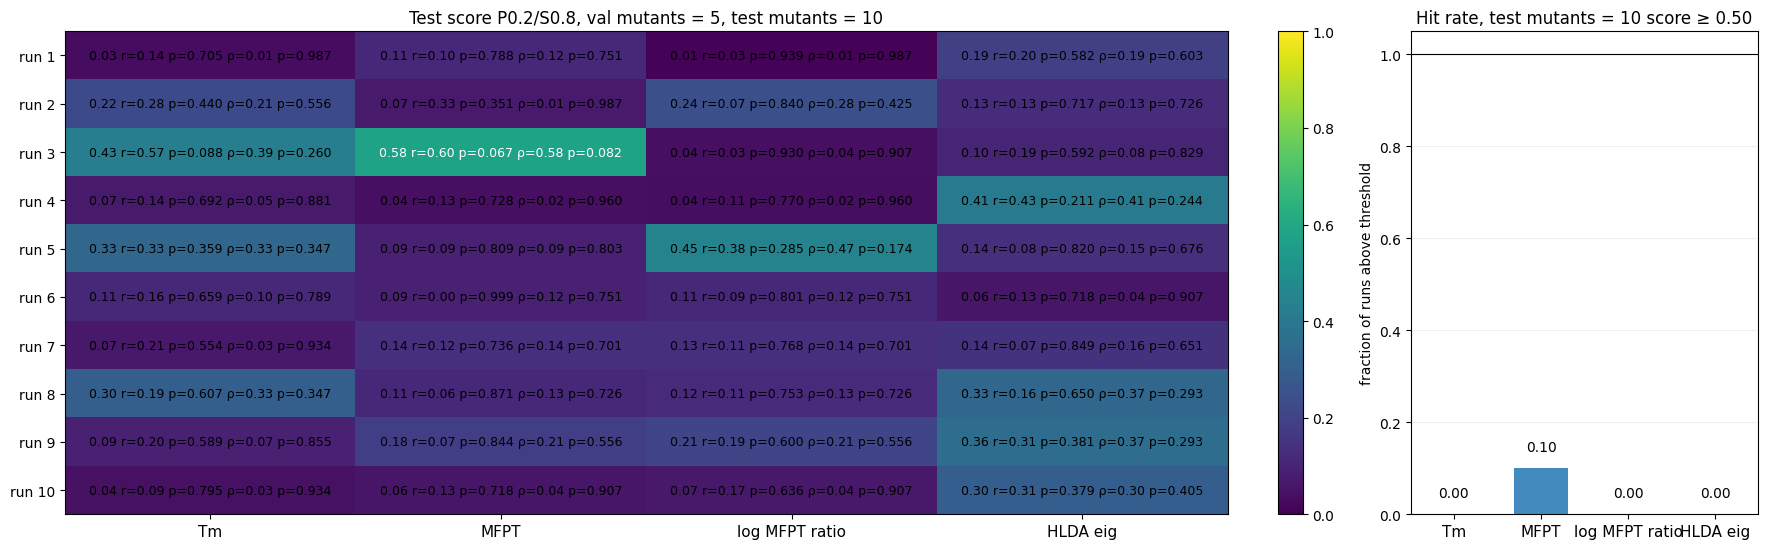

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.2/S0.8, val mutants = 8, test mutants = 7


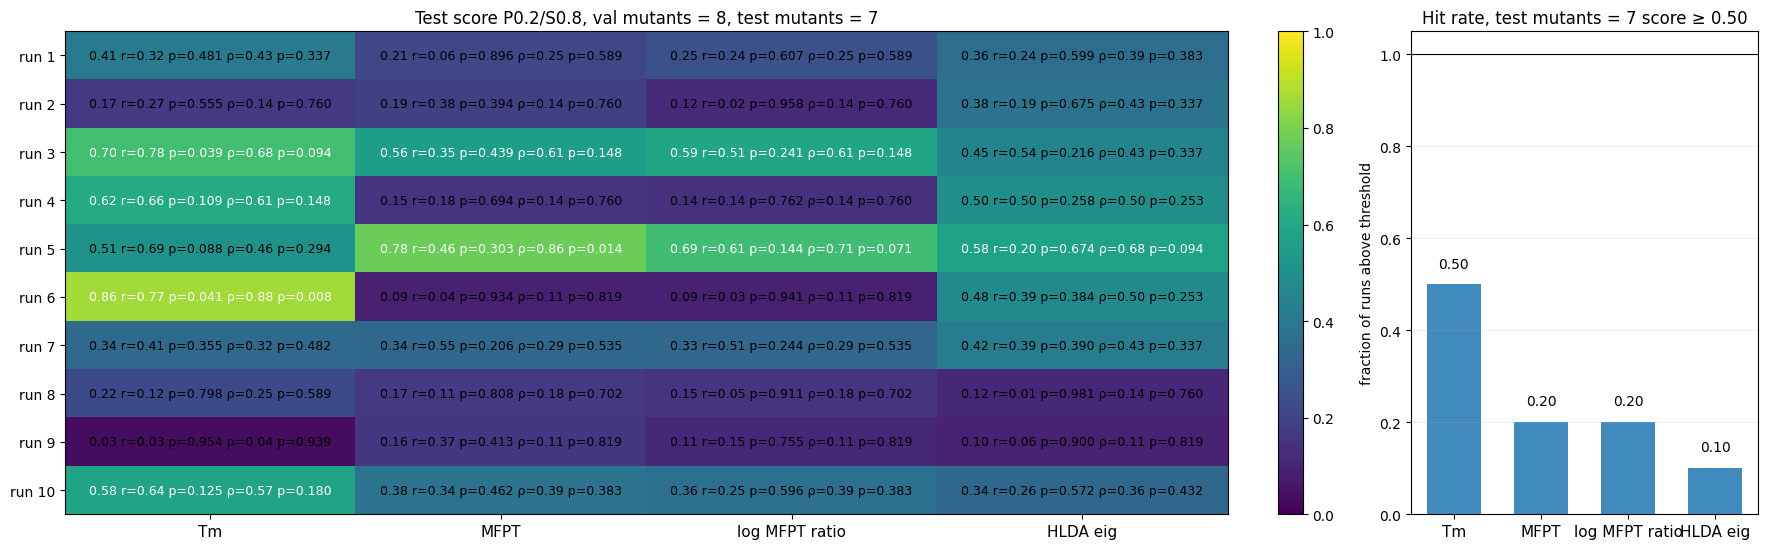

Metric labels: Tm=Tm, MFPT=mfpt, log MFPT ratio=log_mfpt_ratio, HLDA eig=hlda_evalue
P0.2/S0.8, val mutants = 11, test mutants = 4


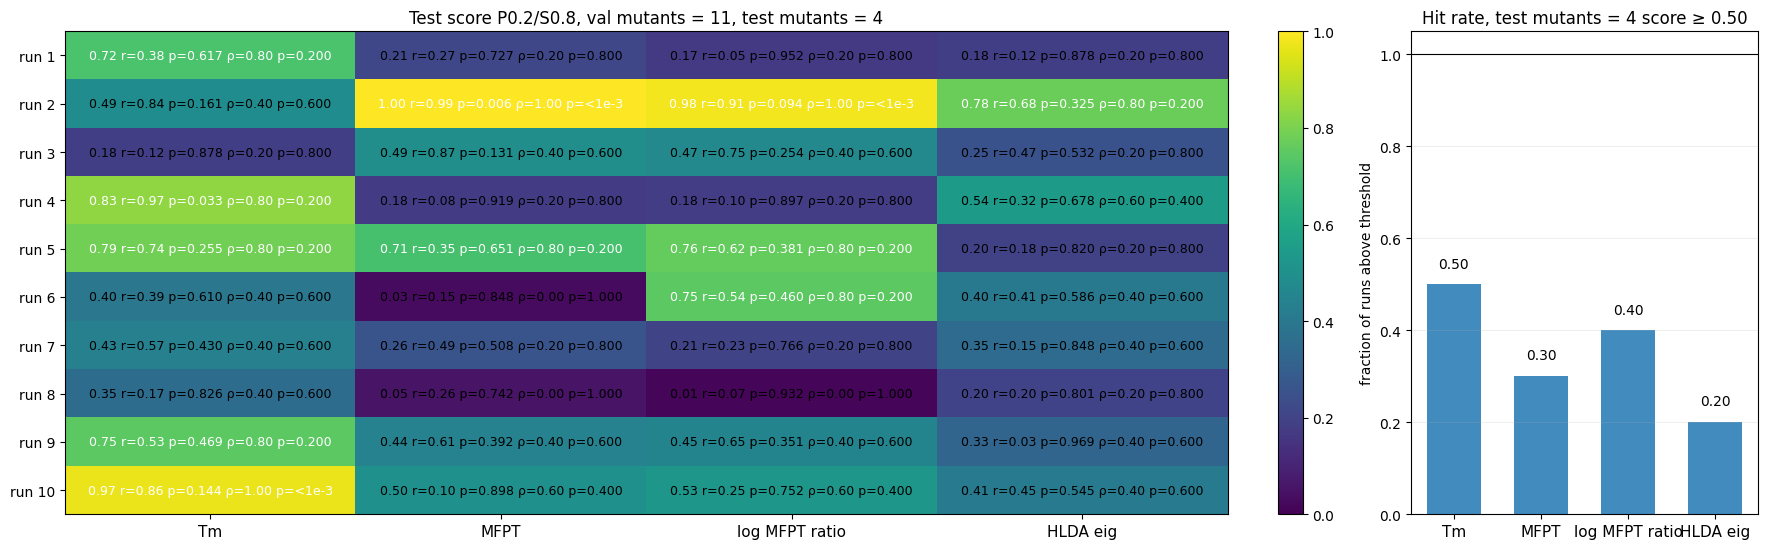

In [41]:
weighted_run_reports = ensure_weighted_run_reports()
for weight_label, report_df in weighted_run_reports.items():
    for selected_analysis_val_mutants in analysis_val_mutant_counts:
        render_score_matrix(report_df, weight_label, selected_analysis_val_mutants)


In [42]:
weighted_run_reports = ensure_weighted_run_reports()
weighted_strength_rows = []
for weight_label, report_df in weighted_run_reports.items():
    tmp = (
        report_df
        .groupby(['analysis_val_mutants', 'metric'], as_index=False)[['test_score', 'test_abs_pearson', 'test_abs_spearman']]
        .mean()
    )
    tmp['weight_label'] = weight_label
    weighted_strength_rows.append(tmp)
metric_strength_df = pd.concat(weighted_strength_rows, ignore_index=True)
print('Average test strength by metric, analysis split choice, and weight setting')
metric_strength_df.sort_values(['weight_label', 'analysis_val_mutants', 'test_score'], ascending=[True, True, False]).round(3)


Average test strength by metric, analysis split choice, and weight setting


,analysis_val_mutants,metric,test_score,test_abs_pearson,test_abs_spearman,weight_label
25,5,hlda_evalue,0.216,0.203,0.219,P0.2/S0.8
24,5,Tm,0.171,0.230,0.156,P0.2/S0.8
27,5,mfpt,0.148,0.163,0.144,P0.2/S0.8
26,5,log_mfpt_ratio,0.142,0.129,0.145,P0.2/S0.8
28,8,Tm,0.444,0.469,0.438,P0.2/S0.8
29,8,hlda_evalue,0.373,0.278,0.396,P0.2/S0.8
31,8,mfpt,0.303,0.284,0.307,P0.2/S0.8
30,8,log_mfpt_ratio,0.285,0.251,0.293,P0.2/S0.8
32,11,Tm,0.592,0.558,0.600,P0.2/S0.8
34,11,log_mfpt_ratio,0.451,0.416,0.460,P0.2/S0.8
